# Descriptive healthcare access analysis

This notebook reads the curated healthcare facility CSVs, the pipeline source/target parquet files, and the 150 km capped distance matrices for Portugal and the Netherlands. It computes descriptive access tables and example graphics, including:

- closest facility overall for each population point;
- closest layer 1 facility for each population point;
- closest layer 2 facility for each population point;
- closest layer 3 facility for each population point;
- per-hospital catchment summaries: percentage of national population for which each hospital is the closest layer 1 facility.

Layer convention used here:

- layer 1: hospital / hospital emergency;
- layer 2: huisartsenpost / permanent care / SAP-like urgent primary care;
- layer 3: general practitioner / primary care.

The distance matrices were produced with table-only sources, split outputs, no generated candidates, no extra amenity reads, and a 150 km cap.

In [2]:
###############################################################################################
#                               Adjust to your current working directory.
###############################################################################################


from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

REPO = Path(r"C:\local\GIT\Public-Infrastructure-Service-Access")
SHARE_ROOT = Path(r"C:\Users\joaqu\OneDrive - UvA\share")
CURRENT_ROOT = Path(r"C:\Users\johne\OneDrive - UvA\Documents\Professional\University of Amsterdam\Master's Thesis\MSc_Thesis_Healthcare_Accessibility\Public-Infrastructure-Service-Access\Research-Sandbox\Master_Theses\DSBA_2025_2026\Jack Martin")

COUNTRIES = {
    "portugal": {
        "facility_csv": CURRENT_ROOT / "Baoshan Liang" / "healthcare_access_analysis" / "facilities" / "portugal_health_service_locations_pipeline_with_permanent_care_geocoded.csv",
        "matrix": CURRENT_ROOT / "Baoshan Liang" / "healthcare_access_analysis" / "distances" / "distance_matrix_src_table_dst_population_pop_1_sample_1_max_none_agg_20_maxdist_150000_amenity_amenity_all-dst_population-src_table_portugal_health_service_locations_pi_9220fa425f_no_candidates.parquet",
        "sources": CURRENT_ROOT / "Baoshan Liang" / "healthcare_access_analysis" / "distances" / "sources_pop_1_sample_1_max_none_agg_20_maxdist_150000_amenity_amenity_all-dst_population-src_table_portugal_health_service_locations_pi_9220fa425f_no_candidates.parquet",
        "targets": CURRENT_ROOT / "Baoshan Liang" / "healthcare_access_analysis" / "distances" / "targets_pop_1_sample_1_max_none_agg_20_maxdist_150000_amenity_amenity_all-dst_population-src_table_portugal_health_service_locations_pi_9220fa425f_no_candidates.parquet",
        "layer_map": {
            "hospital_emergency_official": "layer_1",
            "permanent_care_geocoded": "layer_2",
            "primary_care": "layer_3",
        },
    },
    "netherlands": {
        "facility_csv": CURRENT_ROOT / "Jack Martin" / "healthcare_access_analysis" / "facilities" / "netherlands_health_service_locations_study_layers_european_nl.csv",
        "matrix": CURRENT_ROOT / "Jack Martin" / "healthcare_access_analysis" / "distances" / "distance_matrix_src_table_dst_population_pop_1_sample_1_max_none_agg_20_maxdist_150000_amenity_amenity_all-dst_population-src_table_netherlands_health_service_locations_d979d68da5_no_candidates.parquet",
        "sources": CURRENT_ROOT / "Jack Martin" / "healthcare_access_analysis" / "distances" / "sources_pop_1_sample_1_max_none_agg_20_maxdist_150000_amenity_amenity_all-dst_population-src_table_netherlands_health_service_locations_d979d68da5_no_candidates.parquet",
        "targets": CURRENT_ROOT / "Jack Martin" / "healthcare_access_analysis" / "distances" / "targets_pop_1_sample_1_max_none_agg_20_maxdist_150000_amenity_amenity_all-dst_population-src_table_netherlands_health_service_locations_d979d68da5_no_candidates.parquet",
        "layer_map": {
            "hospital": "layer_1",
            "huisartsenpost": "layer_2",
            "general_practitioner": "layer_3",
        },
    },
}

OUT_DIR = CURRENT_ROOT / "healthcare_access_descriptive_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

for country, cfg in COUNTRIES.items():
    for key in ["facility_csv", "matrix", "sources", "targets"]:
        assert cfg[key].exists(), f"Missing {country} {key}: {cfg[key]}"

COUNTRIES

{'portugal': {'facility_csv': WindowsPath("C:/Users/johne/OneDrive - UvA/Documents/Professional/University of Amsterdam/Master's Thesis/MSc_Thesis_Healthcare_Accessibility/Public-Infrastructure-Service-Access/Research-Sandbox/Master_Theses/DSBA_2025_2026/Jack Martin/Baoshan Liang/healthcare_access_analysis/facilities/portugal_health_service_locations_pipeline_with_permanent_care_geocoded.csv"),
  'matrix': WindowsPath("C:/Users/johne/OneDrive - UvA/Documents/Professional/University of Amsterdam/Master's Thesis/MSc_Thesis_Healthcare_Accessibility/Public-Infrastructure-Service-Access/Research-Sandbox/Master_Theses/DSBA_2025_2026/Jack Martin/Baoshan Liang/healthcare_access_analysis/distances/distance_matrix_src_table_dst_population_pop_1_sample_1_max_none_agg_20_maxdist_150000_amenity_amenity_all-dst_population-src_table_portugal_health_service_locations_pi_9220fa425f_no_candidates.parquet"),
  'sources': WindowsPath("C:/Users/johne/OneDrive - UvA/Documents/Professional/University of Amst

## Helper functions

In [3]:
def weighted_quantile(values, weights, quantiles):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[mask]
    weights = weights[mask]
    if len(values) == 0:
        return [np.nan for _ in quantiles]
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative = cumulative / np.sum(weights)
    return np.interp(quantiles, cumulative, values).tolist()


def prepare_source_lookup(country):
    cfg = COUNTRIES[country]
    facilities = pd.read_csv(cfg["facility_csv"])
    facilities["facility_id"] = facilities["facility_id"].astype(str)
    facilities["source_id"] = "source_table_" + facilities["facility_id"]
    facilities["analysis_layer"] = facilities["layer"].map(cfg["layer_map"])
    facilities["facility_name"] = facilities["name"].fillna(facilities["facility_id"])

    sources = pd.read_parquet(cfg["sources"], columns=["ID", "Longitude", "Latitude", "dist_snap_source"])
    sources = sources.rename(columns={
        "ID": "source_id",
        "Longitude": "source_longitude",
        "Latitude": "source_latitude",
    })

    keep = [
        "source_id", "facility_id", "facility_name", "layer", "analysis_layer",
        "source", "source_detail", "amenity", "healthcare", "city", "postcode",
    ]
    keep = [col for col in keep if col in facilities.columns]
    lookup = sources.merge(facilities[keep], on="source_id", how="left")
    missing = lookup["analysis_layer"].isna().sum()
    if missing:
        print(f"Warning: {country} has {missing} source rows without an analysis layer.")
    return lookup


def prepare_targets(country):
    cfg = COUNTRIES[country]
    targets = pd.read_parquet(cfg["targets"], columns=["ID", "Longitude", "Latitude", "population"])
    return targets.rename(columns={
        "ID": "target_id",
        "Longitude": "target_longitude",
        "Latitude": "target_latitude",
    })


def _minimum_by_target(rows):
    if rows.empty:
        return rows
    return rows.loc[rows.groupby("target_id", sort=False)["total_dist"].idxmin()].copy()


def _update_best(existing, candidate):
    if candidate.empty:
        return existing
    candidate = _minimum_by_target(candidate)
    if existing is None or existing.empty:
        return candidate
    combined = pd.concat([existing, candidate], ignore_index=True)
    return _minimum_by_target(combined)


def compute_closest_tables(country, layers=("layer_1", "layer_2", "layer_3")):
    cfg = COUNTRIES[country]
    source_lookup = prepare_source_lookup(country)
    target_lookup = prepare_targets(country)
    layer_lookup = source_lookup[["source_id", "facility_id", "facility_name", "layer", "analysis_layer"]]

    best = {"overall": None, **{layer: None for layer in layers}}
    matrix_file = pq.ParquetFile(cfg["matrix"])
    columns = ["target_id", "source_id", "total_dist"]

    for group_idx in range(matrix_file.metadata.num_row_groups):
        chunk = matrix_file.read_row_group(group_idx, columns=columns).to_pandas()
        chunk = chunk.merge(layer_lookup, on="source_id", how="left")
        chunk = chunk.dropna(subset=["analysis_layer"])
        best["overall"] = _update_best(best["overall"], chunk)
        for layer in layers:
            best[layer] = _update_best(best[layer], chunk[chunk["analysis_layer"] == layer])

    closest = []
    for category, table in best.items():
        if table is None:
            continue
        table = table.merge(target_lookup, on="target_id", how="left")
        table["closest_category"] = category
        table["distance_km"] = table["total_dist"] / 1000.0
        closest.append(table)
    return pd.concat(closest, ignore_index=True), source_lookup, target_lookup


def access_summary(closest):
    rows = []
    for category, group in closest.groupby("closest_category", sort=False):
        q10, q25, q50, q75, q90 = weighted_quantile(
            group["distance_km"], group["population"], [0.10, 0.25, 0.50, 0.75, 0.90]
        )
        rows.append({
            "closest_category": category,
            "population_covered": group["population"].sum(),
            "population_points": group["target_id"].nunique(),
            "weighted_mean_km": np.average(group["distance_km"], weights=group["population"]),
            "weighted_p10_km": q10,
            "weighted_p25_km": q25,
            "weighted_median_km": q50,
            "weighted_p75_km": q75,
            "weighted_p90_km": q90,
        })
    return pd.DataFrame(rows)


def hospital_catchment_summary(closest):
    hospitals = closest[closest["closest_category"] == "layer_1"].copy()
    total_population = hospitals["population"].sum()
    summary = (
        hospitals.groupby(["source_id", "facility_id", "facility_name"], dropna=False)
        .agg(
            closest_population=("population", "sum"),
            population_points=("target_id", "nunique"),
            weighted_mean_distance_km=("distance_km", lambda s: np.average(s, weights=hospitals.loc[s.index, "population"])),
            min_distance_km=("distance_km", "min"),
            max_distance_km=("distance_km", "max"),
        )
        .reset_index()
    )
    summary["closest_population_pct"] = 100 * summary["closest_population"] / total_population
    return summary.sort_values("closest_population_pct", ascending=False)


def save_country_outputs(country, closest, source_lookup, target_lookup):
    country_dir = OUT_DIR / country
    country_dir.mkdir(parents=True, exist_ok=True)
    closest.to_parquet(country_dir / "closest_facility_by_population_point.parquet", index=False)
    source_lookup.to_csv(country_dir / "source_lookup_with_analysis_layers.csv", index=False)
    target_lookup.to_csv(country_dir / "target_population_points.csv", index=False)
    access_summary(closest).to_csv(country_dir / "distance_summary_by_closest_category.csv", index=False)
    hospital_catchment_summary(closest).to_csv(country_dir / "hospital_closest_population_share.csv", index=False)
    return country_dir

## Run the closest-facility analysis

This cell scans each distance matrix row group and keeps only the current minimum distance per population point and layer. On a normal workstation it is much lighter than materializing all matrix rows plus joins at once, but it still reads the full matrix files.

In [4]:
results = {}

for country in COUNTRIES:
    print(f"Processing {country}...")
    closest, source_lookup, target_lookup = compute_closest_tables(country)
    output_dir = save_country_outputs(country, closest, source_lookup, target_lookup)
    results[country] = {
        "closest": closest,
        "source_lookup": source_lookup,
        "target_lookup": target_lookup,
        "access_summary": access_summary(closest),
        "hospital_catchments": hospital_catchment_summary(closest),
        "output_dir": output_dir,
    }
    print(f"  wrote outputs to {output_dir}")

Processing portugal...
  wrote outputs to C:\Users\johne\OneDrive - UvA\Documents\Professional\University of Amsterdam\Master's Thesis\MSc_Thesis_Healthcare_Accessibility\Public-Infrastructure-Service-Access\Research-Sandbox\Master_Theses\DSBA_2025_2026\Jack Martin\healthcare_access_descriptive_outputs\portugal
Processing netherlands...
  wrote outputs to C:\Users\johne\OneDrive - UvA\Documents\Professional\University of Amsterdam\Master's Thesis\MSc_Thesis_Healthcare_Accessibility\Public-Infrastructure-Service-Access\Research-Sandbox\Master_Theses\DSBA_2025_2026\Jack Martin\healthcare_access_descriptive_outputs\netherlands


## Descriptive tables

In [5]:
for country, result in results.items():
    print(f"\n{country.upper()} distance summary")
    display(result["access_summary"])
    print(f"\n{country.upper()} hospitals serving the largest closest-population shares")
    display(result["hospital_catchments"].head(15))


PORTUGAL distance summary


,closest_category,population_covered,population_points,weighted_mean_km,weighted_p10_km,weighted_p25_km,weighted_median_km,weighted_p75_km,weighted_p90_km
0,overall,1.012775e+07,22822,3.166461,0.597904,1.062024,1.835920,3.875168,7.464111
1,layer_1,1.008751e+07,22516,10.111111,1.906867,3.555830,7.554272,13.712831,22.058345
2,layer_2,8.852545e+06,17193,56.873220,7.535399,17.748241,54.876297,85.636838,115.366623
3,layer_3,1.012775e+07,22822,3.252463,0.607889,1.087493,1.879551,3.961646,7.659082



PORTUGAL hospitals serving the largest closest-population shares


,source_id,facility_id,facility_name,closest_population,population_points,weighted_mean_distance_km,min_distance_km,max_distance_km,closest_population_pct
33,source_table_sns_urgency:4,sns_urgency:4,Urgência do Hospital São João - Porto,460584.682523,86,6.636198,0.994241,21.668587,4.565890
32,source_table_sns_urgency:39,sns_urgency:39,Urgência do Hospital Santa Maria,365319.084515,27,5.183127,0.783607,14.626347,3.621498
93,source_table_sns_urgency:94,sns_urgency:94,SUB Algueirão Mem-Martins,324704.787052,135,7.720942,1.199858,26.453419,3.218879
65,source_table_sns_urgency:69,sns_urgency:69,Urgência do Hospital Beatriz Ângelo - Loures,322902.012528,106,8.239813,2.037050,22.768179,3.201007
66,source_table_sns_urgency:7,sns_urgency:7,Urgência do Hospital Garcia de Orta,313287.767594,60,6.600952,0.783557,17.944166,3.105699
18,source_table_sns_urgency:26,sns_urgency:26,Urgência do Hospital Prof. Doutor Fernando Fon...,296472.375872,22,4.776842,2.071441,10.269044,2.939004
12,source_table_sns_urgency:20,sns_urgency:20,Urgência do Hospital Padre Américo - Vale do S...,254561.407715,212,10.821797,0.410342,25.430449,2.523530
23,source_table_sns_urgency:30,sns_urgency:30,Urgência do Hospital Eduardo Santos Silva - Ga...,251305.473988,74,6.443273,1.130756,28.011966,2.491253
26,source_table_sns_urgency:33,sns_urgency:33,Urgência do Hospital Dr. Nélio de Mendonça (Cr...,250710.821812,225,11.693575,1.180812,53.167032,2.485358
0,source_table_sns_urgency:1,sns_urgency:1,Urgência do Hospital de Braga,249650.117472,250,8.254499,1.179310,50.500279,2.474843



NETHERLANDS distance summary


,closest_category,population_covered,population_points,weighted_mean_km,weighted_p10_km,weighted_p25_km,weighted_median_km,weighted_p75_km,weighted_p90_km
0,overall,1.646878e+07,16580,2.549918,0.586239,1.015826,1.956233,3.442153,5.398103
1,layer_1,1.644757e+07,16344,10.007779,2.546936,4.352871,8.350665,14.162895,20.035002
2,layer_2,1.646036e+07,16432,7.886341,2.281387,3.843769,6.620588,10.924396,15.450046
3,layer_3,1.646878e+07,16580,2.590521,0.599031,1.032065,2.004924,3.489675,5.459199



NETHERLANDS hospitals serving the largest closest-population shares


,source_id,facility_id,facility_name,closest_population,population_points,weighted_mean_distance_km,min_distance_km,max_distance_km,closest_population_pct
33,source_table_vzinfo_seh:104805,vzinfo_seh:104805,HagaZiekenhuis locatie Leyweg Den Haag,617232.845388,82,5.571455,1.050780,16.241829,3.752730
43,source_table_vzinfo_seh:105901,vzinfo_seh:105901,ETZ Elisabeth Tilburg,515484.005596,428,13.848636,1.683001,32.866427,3.134105
51,source_table_vzinfo_seh:106901,vzinfo_seh:106901,Hilversum,439920.540747,179,11.643149,0.957302,24.003175,2.674685
47,source_table_vzinfo_seh:106304,vzinfo_seh:106304,OLVG locatie West Amsterdam,399578.042249,53,4.825345,0.816696,11.911426,2.429405
21,source_table_vzinfo_seh:103007,vzinfo_seh:103007,Jeroen Bosch Ziekenhuis 's-Hertogenbosch,382488.617693,292,10.443490,2.231103,24.558753,2.325503
19,source_table_vzinfo_seh:102801,vzinfo_seh:102801,Ikazia Ziekenhuis Rotterdam,351801.475619,171,11.854233,1.239129,31.189231,2.138927
20,source_table_vzinfo_seh:102902,vzinfo_seh:102902,Isala Zwolle,336844.918476,505,14.156388,0.370508,44.841840,2.047992
42,source_table_vzinfo_seh:105806,vzinfo_seh:105806,St. Antonius Ziekenhuis Utrecht,331114.713933,158,8.345767,1.484437,22.772592,2.013153
2,source_table_vzinfo_seh:100301,vzinfo_seh:100301,Albert Schweitzer Ziekenhuis Dordrecht,327724.257409,216,9.233086,1.023122,29.022745,1.992539
5,source_table_vzinfo_seh:100701,vzinfo_seh:100701,Zuyderland Medisch Centrum locatie Heerlen,325205.016311,183,10.389092,1.347628,24.650545,1.977223


## Graphics

In [6]:
for category, group in closest.groupby("closest_category", sort=False):
    print(category)

overall
layer_1
layer_2
layer_3


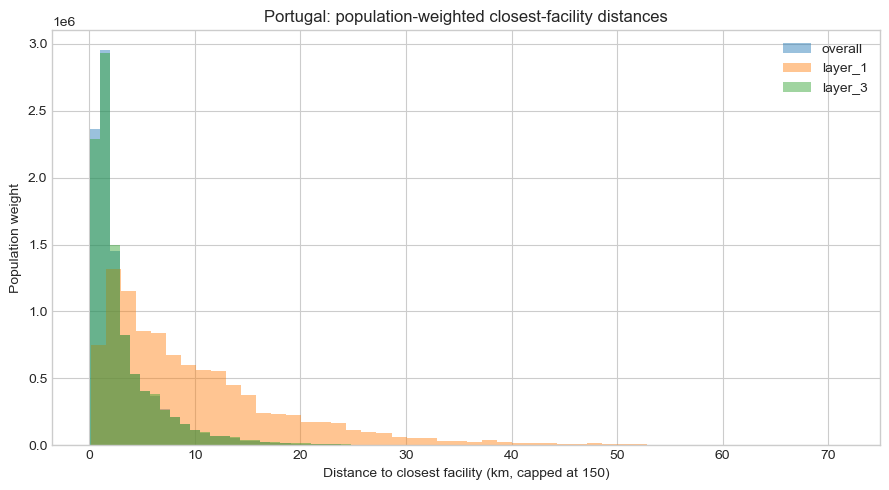

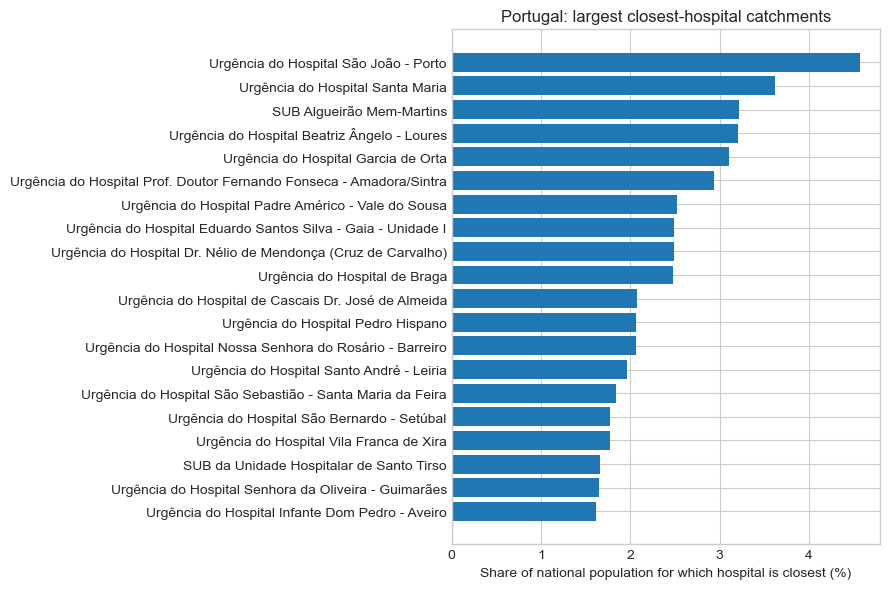

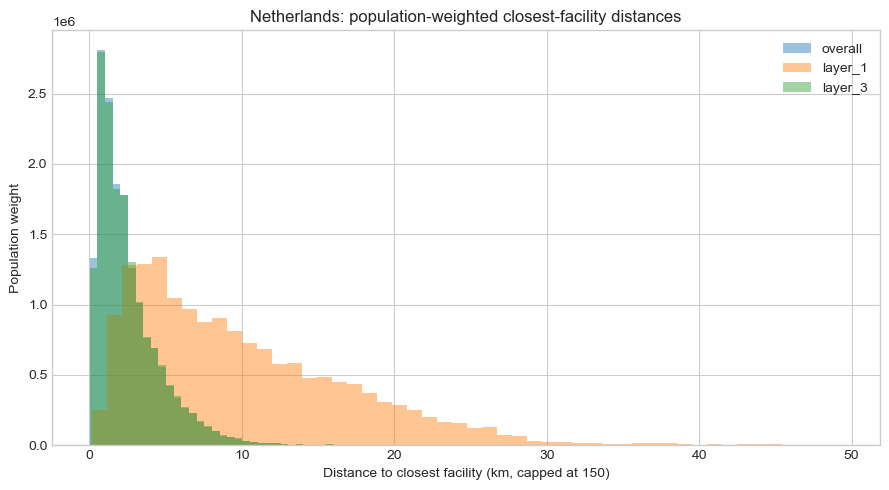

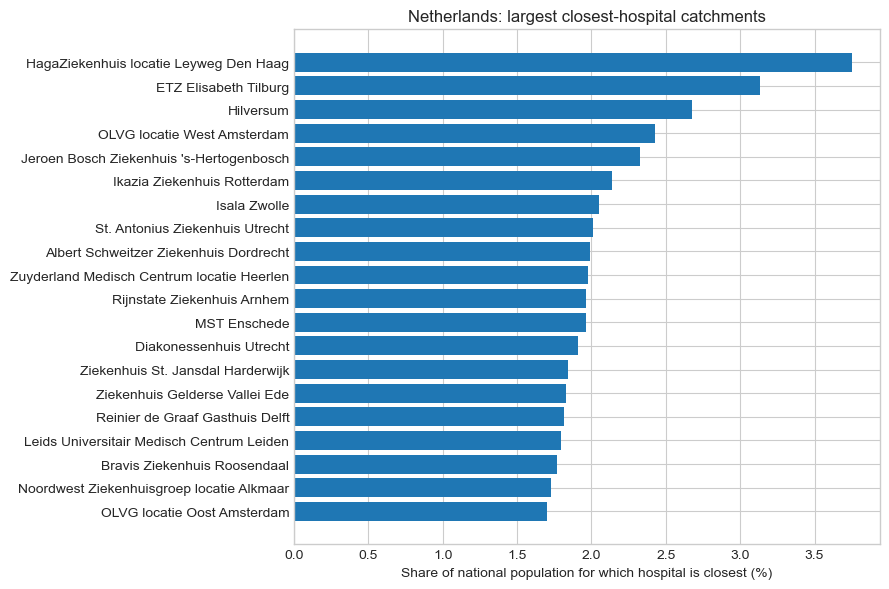

In [7]:
plt.style.use("seaborn-v0_8-whitegrid")

for country, result in results.items():
    closest = result["closest"]

    closest = closest[closest["closest_category"].str.contains("overall|layer_1|layer_3")]

    fig, ax = plt.subplots(figsize=(9, 5))
    for category, group in closest.groupby("closest_category", sort=False):
        distances = group["distance_km"].clip(upper=150)
        ax.hist(distances, bins=50, alpha=0.45, weights=group["population"], label=category)
    ax.set_title(f"{country.title()}: population-weighted closest-facility distances")
    ax.set_xlabel("Distance to closest facility (km, capped at 150)")
    ax.set_ylabel("Population weight")
    ax.legend()
    fig.tight_layout()
    fig.savefig(result["output_dir"] / "weighted_distance_histogram.png", dpi=180)
    plt.show()

    top = result["hospital_catchments"].head(20).copy()
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top["facility_name"].iloc[::-1], top["closest_population_pct"].iloc[::-1])
    ax.set_title(f"{country.title()}: largest closest-hospital catchments")
    ax.set_xlabel("Share of national population for which hospital is closest (%)")
    ax.set_ylabel("")
    fig.tight_layout()
    fig.savefig(result["output_dir"] / "top_hospital_closest_population_share.png", dpi=180)
    plt.show()

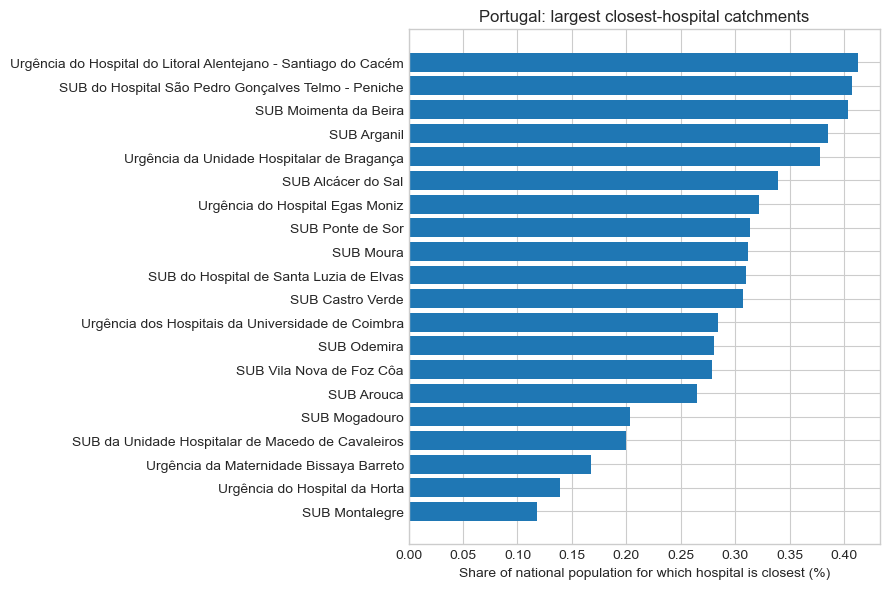

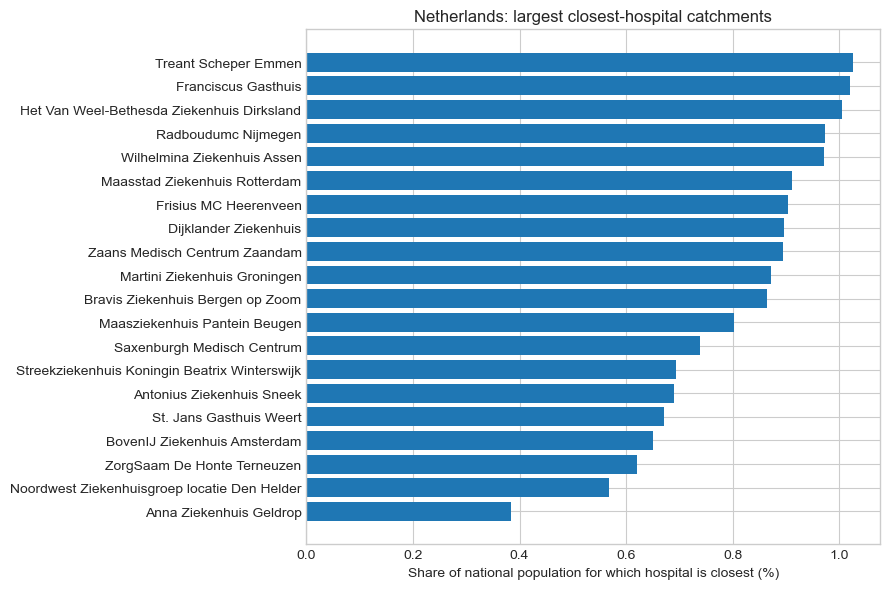

In [8]:
for country, result in results.items():

    top = result["hospital_catchments"].tail(20).copy()
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top["facility_name"].iloc[::-1], top["closest_population_pct"].iloc[::-1])
    ax.set_title(f"{country.title()}: largest closest-hospital catchments")
    ax.set_xlabel("Share of national population for which hospital is closest (%)")
    ax.set_ylabel("")
    fig.tight_layout()
    fig.savefig(result["output_dir"] / "top_hospital_closest_population_share.png", dpi=180)
    plt.show()

## Simple spatial context plots

These are not replacement cartographic context figures. They are quick checks showing target population points colored by nearest layer 1 distance and facility points by analysis layer.

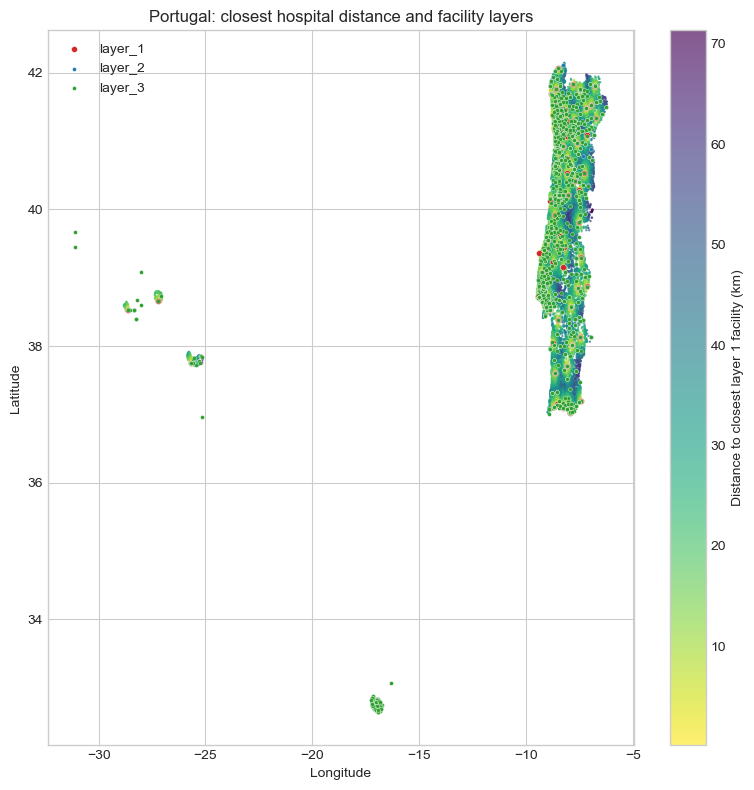

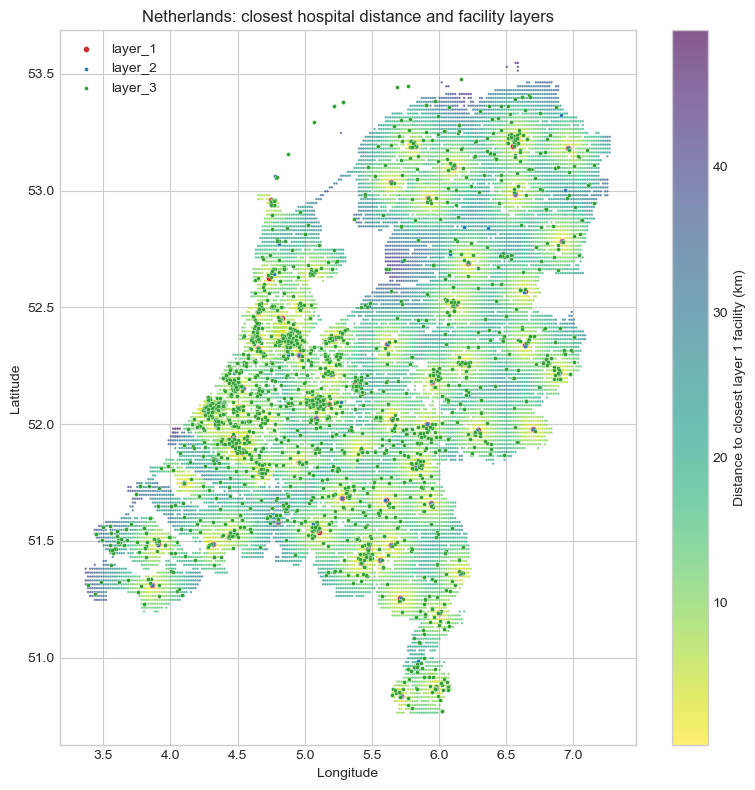

In [9]:
layer_colors = {"layer_1": "#d62728", "layer_2": "#1f77b4", "layer_3": "#2ca02c"}

for country, result in results.items():
    closest = result.get("closest")
    if closest is None or "closest_category" not in closest.columns:
        saved_closest = result.get("output_dir", OUT_DIR / country) / "closest_facility_by_population_point.parquet"
        if saved_closest.exists():
            closest = pd.read_parquet(saved_closest)
            result["closest"] = closest
        else:
            raise KeyError(
                f"{country}: result['closest'] does not contain closest_category. "
                "Run the closest-facility analysis cell before plotting."
            )

    layer1 = closest[closest["closest_category"] == "layer_1"].copy()
    if layer1.empty:
        print(f"Skipping {country}: no layer_1 closest rows available.")
        continue

    sources = result["source_lookup"].dropna(subset=["analysis_layer"])

    fig, ax = plt.subplots(figsize=(8, 8))
    sc = ax.scatter(
        layer1["target_longitude"],
        layer1["target_latitude"],
        c=layer1["distance_km"],
        s=np.clip(layer1["population"] / layer1["population"].quantile(0.95), 0.5, 12),
        cmap="viridis_r",
        alpha=0.65,
    )
    for layer, group in sources.groupby("analysis_layer"):
        ax.scatter(
            group["source_longitude"],
            group["source_latitude"],
            s=18 if layer == "layer_1" else 8,
            c=layer_colors.get(layer, "black"),
            label=layer,
            edgecolor="white",
            linewidth=0.25,
        )
    ax.set_title(f"{country.title()}: closest hospital distance and facility layers")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(loc="best")
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Distance to closest layer 1 facility (km)")
    fig.tight_layout()
    fig.savefig(result["output_dir"] / "closest_hospital_distance_spatial_check.png", dpi=180)
    plt.show()

# Inspect the Data

In [10]:
results["netherlands"].keys() # Closest, source_lookup, target_lookup, acces_summary, hospital_catchments, output_dir

dict_keys(['closest', 'source_lookup', 'target_lookup', 'access_summary', 'hospital_catchments', 'output_dir'])

In [11]:
results["netherlands"]["closest"].head()

,target_id,source_id,total_dist,facility_id,facility_name,layer,analysis_layer,target_longitude,target_latitude,population,closest_category,distance_km
0,target_population_11882,source_table_osm:node:2800617171,9079.526076,osm:node:2800617171,osm:node:2800617171,general_practitioner,layer_3,6.786250,51.913750,30.452981,overall,9.079526
1,target_population_15540,source_table_osm:node:7773371820,2144.523488,osm:node:7773371820,Huisartsenpraktijk Van den Top,general_practitioner,layer_3,5.552917,51.480417,2438.710058,overall,2.144523
2,target_population_15541,source_table_osm:node:7773371820,3588.956713,osm:node:7773371820,Huisartsenpraktijk Van den Top,general_practitioner,layer_3,5.569583,51.480417,1768.620365,overall,3.588957
3,target_population_10205,source_table_osm:way:58048292,3398.569859,osm:way:58048292,Fabels,general_practitioner,layer_3,6.086250,52.080417,520.600568,overall,3.398570
4,target_population_9246,source_table_osm:node:2731679175,7989.744081,osm:node:2731679175,Huisartsenpraktijk Stroe,general_practitioner,layer_3,5.786250,52.180417,139.139891,overall,7.989744


In [12]:
results["netherlands"]["source_lookup"].head(2)

,source_id,source_longitude,source_latitude,dist_snap_source,facility_id,facility_name,layer,analysis_layer,source,source_detail,amenity,healthcare,city,postcode
0,source_table_osm:node:253446344,5.419288,51.882909,45.235982,osm:node:253446344,osm:node:253446344,general_practitioner,layer_3,OpenStreetMap via Overpass API,OSM tags: amenity=doctors OR healthcare=doctor...,doctors,doctor,NaN,NaN
1,source_table_osm:node:331976982,6.886618,52.661043,15.289922,osm:node:331976982,osm:node:331976982,general_practitioner,layer_3,OpenStreetMap via Overpass API,OSM tags: amenity=doctors OR healthcare=doctor...,doctors,doctor,NaN,NaN


In [13]:
results["netherlands"]["source_lookup"]

,source_id,source_longitude,source_latitude,dist_snap_source,facility_id,facility_name,layer,analysis_layer,source,source_detail,amenity,healthcare,city,postcode
0,source_table_osm:node:253446344,5.419288,51.882909,45.235982,osm:node:253446344,osm:node:253446344,general_practitioner,layer_3,OpenStreetMap via Overpass API,OSM tags: amenity=doctors OR healthcare=doctor...,doctors,doctor,NaN,NaN
1,source_table_osm:node:331976982,6.886618,52.661043,15.289922,osm:node:331976982,osm:node:331976982,general_practitioner,layer_3,OpenStreetMap via Overpass API,OSM tags: amenity=doctors OR healthcare=doctor...,doctors,doctor,NaN,NaN
2,source_table_osm:node:409816901,4.285849,52.033323,73.116736,osm:node:409816901,osm:node:409816901,general_practitioner,layer_3,OpenStreetMap via Overpass API,OSM tags: amenity=doctors OR healthcare=doctor...,doctors,NaN,NaN,NaN
3,source_table_osm:node:672366383,5.420985,51.327385,15.533014,osm:node:672366383,osm:node:672366383,general_practitioner,layer_3,OpenStreetMap via Overpass API,OSM tags: amenity=doctors OR healthcare=doctor...,doctors,doctor,NaN,NaN
4,source_table_osm:node:746911697,4.808973,52.346218,18.637821,osm:node:746911697,osm:node:746911697,general_practitioner,layer_3,OpenStreetMap via Overpass API,OSM tags: amenity=doctors OR healthcare=doctor...,doctors,doctor,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2536,source_table_vzinfo_seh:108701,5.415471,51.889525,29.499098,vzinfo_seh:108701,Ziekenhuis Rivierenland Tiel,hospital,layer_1,RIVM/VZinfo,Reistijd naar dichtstbijzijnde ziekenhuis met ...,NaN,NaN,Tiel,4002WP
2537,source_table_vzinfo_seh:106201,5.614296,52.344156,3.279240,vzinfo_seh:106201,Ziekenhuis St. Jansdal Harderwijk,hospital,layer_1,RIVM/VZinfo,Reistijd naar dichtstbijzijnde ziekenhuis met ...,NaN,NaN,Harderwijk,3844DG
2538,source_table_vzinfo_seh:109002,6.641227,52.337609,3.724169,vzinfo_seh:109002,Ziekenhuisgroep Twente Almelo,hospital,layer_1,RIVM/VZinfo,Reistijd naar dichtstbijzijnde ziekenhuis met ...,NaN,NaN,Almelo,7609PP
2539,source_table_vzinfo_seh:108801,3.861353,51.308957,14.935462,vzinfo_seh:108801,ZorgSaam De Honte Terneuzen,hospital,layer_1,RIVM/VZinfo,Reistijd naar dichtstbijzijnde ziekenhuis met ...,NaN,NaN,Terneuzen,4535PA


In [14]:
results["netherlands"]["target_lookup"].head()

,target_id,target_longitude,target_latitude,population
0,target_population_0,6.452917,53.547083,3.116480
1,target_population_1,6.469583,53.547083,18.261614
2,target_population_2,6.486250,53.547083,10.389469
3,target_population_3,6.502917,53.547083,1.108934
4,target_population_4,6.569583,53.547083,6.779233


In [15]:
results["netherlands"]["access_summary"] # Notice the large difference between the mean and the median: usually around 1-2 kilometers.
# Indicates a skewed distribution with extreme values or outliers

,closest_category,population_covered,population_points,weighted_mean_km,weighted_p10_km,weighted_p25_km,weighted_median_km,weighted_p75_km,weighted_p90_km
0,overall,1.646878e+07,16580,2.549918,0.586239,1.015826,1.956233,3.442153,5.398103
1,layer_1,1.644757e+07,16344,10.007779,2.546936,4.352871,8.350665,14.162895,20.035002
2,layer_2,1.646036e+07,16432,7.886341,2.281387,3.843769,6.620588,10.924396,15.450046
3,layer_3,1.646878e+07,16580,2.590521,0.599031,1.032065,2.004924,3.489675,5.459199


In [16]:
results["netherlands"]["hospital_catchments"].head() # Individual hospital information. How many people do the hospitals cover.
# Quick verification: it states that the Haga Ziekenhuis locatie Leyweg covers over six hundred thousand people. Does this make sense?
# Likely not if it is a general practitioner (primary care) facility but maybe it makes more sense as a hospital (ziekenhuis) that would have to serve a much larger population.
#   To say something more about the congestion at the hospital we have to say something about the incidence of a population member visiting the Ziekenhuis, and how quickly the Ziekenhuis can treat patients.

,source_id,facility_id,facility_name,closest_population,population_points,weighted_mean_distance_km,min_distance_km,max_distance_km,closest_population_pct
33,source_table_vzinfo_seh:104805,vzinfo_seh:104805,HagaZiekenhuis locatie Leyweg Den Haag,617232.845388,82,5.571455,1.050780,16.241829,3.752730
43,source_table_vzinfo_seh:105901,vzinfo_seh:105901,ETZ Elisabeth Tilburg,515484.005596,428,13.848636,1.683001,32.866427,3.134105
51,source_table_vzinfo_seh:106901,vzinfo_seh:106901,Hilversum,439920.540747,179,11.643149,0.957302,24.003175,2.674685
47,source_table_vzinfo_seh:106304,vzinfo_seh:106304,OLVG locatie West Amsterdam,399578.042249,53,4.825345,0.816696,11.911426,2.429405
21,source_table_vzinfo_seh:103007,vzinfo_seh:103007,Jeroen Bosch Ziekenhuis 's-Hertogenbosch,382488.617693,292,10.443490,2.231103,24.558753,2.325503


In [17]:
results["netherlands"]["hospital_catchments"].tail() # This dataset only talks about the catchmenets for the hospitals. That means that the least used hospital still covers
# a significant amount of th population.
# Question: Is there a correlation between accessibility of a hospital and the amount of the population that it treats?
# Hypothesis: yes because hospitals are located next to big population points. So the larger hospitals should be more accessible.
# Confoudnign variables: availability of land in highly populated areas. Invstment in infratructure depenedent on the amount of peopel that visit the hosiptals.

,source_id,facility_id,facility_name,closest_population,population_points,weighted_mean_distance_km,min_distance_km,max_distance_km,closest_population_pct
44,source_table_vzinfo_seh:106101,vzinfo_seh:106101,St. Jans Gasthuis Weert,110331.061777,211,8.268238,1.434400,21.940418,0.670805
6,source_table_vzinfo_seh:100801,vzinfo_seh:100801,BovenIJ Ziekenhuis Amsterdam,106880.663553,44,4.218129,1.602454,18.663522,0.649827
67,source_table_vzinfo_seh:108801,vzinfo_seh:108801,ZorgSaam De Honte Terneuzen,101949.446649,398,15.602661,1.396473,41.673847,0.619845
28,source_table_vzinfo_seh:103702,vzinfo_seh:103702,Noordwest Ziekenhuisgroep locatie Den Helder,93519.057996,190,11.701123,1.897008,38.067724,0.568589
41,source_table_vzinfo_seh:105701,vzinfo_seh:105701,Anna Ziekenhuis Geldrop,63032.226917,51,4.611967,1.102332,14.417895,0.383231


In [18]:
results["netherlands"]["output_dir"] # Just a string of the output directory.

WindowsPath("C:/Users/johne/OneDrive - UvA/Documents/Professional/University of Amsterdam/Master's Thesis/MSc_Thesis_Healthcare_Accessibility/Public-Infrastructure-Service-Access/Research-Sandbox/Master_Theses/DSBA_2025_2026/Jack Martin/healthcare_access_descriptive_outputs/netherlands")

### Quick note: layer 1 is hospitals (tertiary care), layer 2 is secondary care, layer 3 is primary care.

To me this seems a bit backwards but it is just how the data went in so I could go out of my way to convert it in the data if I need to but it's not necessary. I just need to include it in my results and analysis / discussion.

#   Population density analysis

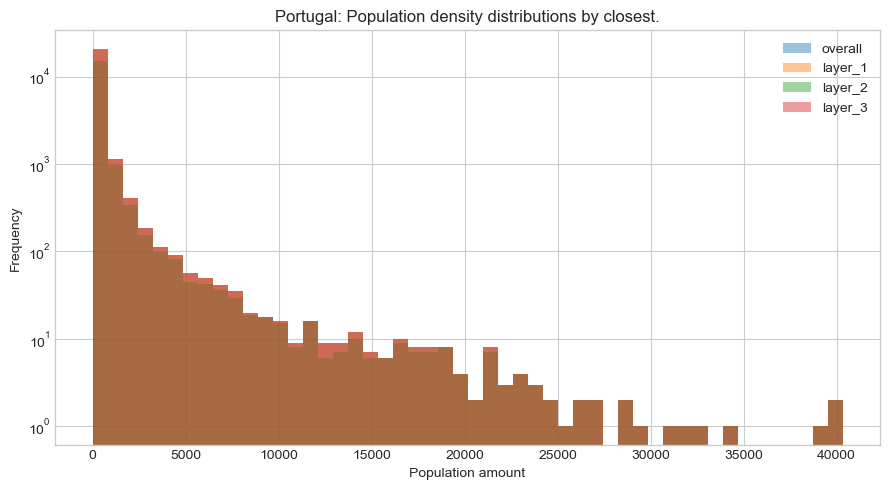

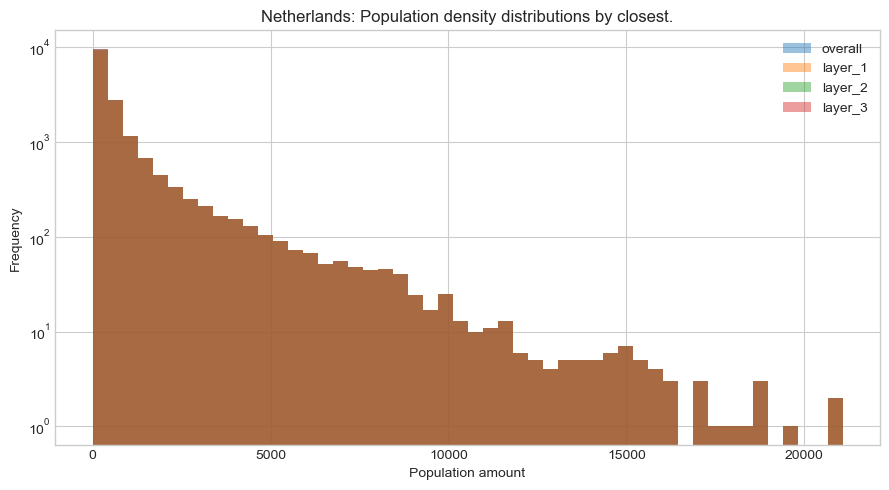

In [19]:
plt.style.use("seaborn-v0_8-whitegrid")

for country, result in results.items():
    closest = result["closest"]
    
    closest_filtered = closest[closest["closest_category"].str.contains("overall|layer_1|layer_2|layer_3")]

    closest
    fig, ax = plt.subplots(figsize=(9, 5))
    for category, group in closest_filtered.groupby("closest_category", sort=False):
        population = group["population"]#.clip(upper=150)
        ax.hist(population, bins=50, alpha=0.45, label=category, log=True)

    ax.set_title(f"{country.title()}: Population density distributions by closest.")
    ax.set_xlabel("Population amount")
    ax.set_ylabel("Frequency")
    ax.legend()
    fig.tight_layout()
    fig.savefig(result["output_dir"] / "weighted_distance_histogram.png", dpi=180)
    plt.show()

# Enhance the Dataset

Load in RIVM Regiobeeld data and NZa Waiting Data.

In [20]:
PATH = Path(r"c:/Users/johne/OneDrive - UvA/Documents/Professional/University of Amsterdam/Master's Thesis/MSc_Thesis_Healthcare_Accessibility/Public-Infrastructure-Service-Access/Research-Sandbox/Master_Theses/DSBA_2025_2026/Jack Martin")

PATH_DATA = PATH / "data"

In [21]:
RIVM_Cijfersoort = pd.read_csv(PATH_DATA / "50148NED_RIVM_dims_Cijfersoort.csv")
RIVM_Perioden = pd.read_csv(PATH_DATA / "50148NED_RIVM_dims_Perioden.csv")
RIVM_RegioS_dims = pd.read_csv(PATH_DATA / "50148NED_RIVM_dims_RegioS.csv")
RIVM_CategoryGroups = pd.read_csv(PATH_DATA / "50148NED_RIVM_meta_CategoryGroups.csv")
RIVM_Cijfersoort = pd.read_csv(PATH_DATA / "50148NED_RIVM_meta_Cijfersoort.csv")
RIVM_DataProperties = pd.read_csv(PATH_DATA / "50148NED_RIVM_meta_DataProperties.csv")
RIVM_Perioden = pd.read_csv(PATH_DATA / "50148NED_RIVM_meta_Perioden.csv")
RIVM_RegioS_meta = pd.read_csv(PATH_DATA / "50148NED_RIVM_meta_RegioS.csv")
RIVM_TableInfos = pd.read_csv(PATH_DATA / "50148NED_RIVM_meta_TableInfos.csv")
RIVM_RIVM = pd.read_csv(PATH_DATA / "50148NED_RIVM.csv")

In [22]:
print(RIVM_TableInfos.columns.to_list())

['Unnamed: 0', 'ID', 'Title', 'ShortTitle', 'Identifier', 'Summary', 'Modified', 'ReasonDelivery', 'ExplanatoryText', 'Language', 'Catalog', 'Frequency', 'Period', 'ShortDescription', 'Description', 'DefaultPresentation', 'DefaultSelection', 'GraphTypes', 'OutputStatus', 'Source', 'MetaDataModified', 'SearchPriority']


In [23]:
RIVM_TableInfos

,Unnamed: 0,ID,Title,ShortTitle,Identifier,Summary,Modified,ReasonDelivery,ExplanatoryText,Language,...,Period,ShortDescription,Description,DefaultPresentation,DefaultSelection,GraphTypes,OutputStatus,Source,MetaDataModified,SearchPriority
0,0,0,"RIVM Regiobeeld; regio (indeling 2024), 1999-2040",RIVM Regiobeeld; regio (indeling 2024),50148NED,"Bevolking, gezondheid, leefstijl, zorggebruik,...",2025-11-11T02:00:00,Nieuw,NaN,nl,...,1999-2040,\nDe cijfers in deze tabel zijn gebaseerd op v...,INHOUDSOPGAVE\r\n\r\n1. Toelichting\r\n2. Defi...,"ts=1762504947778&graphtype=Table&r=Topics,Cijf...",$filter=((RegioS eq 'NL01 ') or (RegioS eq 'P...,"Table,Bar,Line",Regulier,Regiobeeld.nl; Rijksinstituut voor Volksgezond...,2025-11-11T02:00:00,2


In [24]:
print(RIVM_TableInfos.Title.values[0], "\n\n")
print(RIVM_TableInfos.ShortTitle.values[0], "\n\n")
print(RIVM_TableInfos.Identifier.values[0], "\n\n")
print(RIVM_TableInfos.Summary.values[0], "\n\n")
print(RIVM_TableInfos.Language.values[0], "\n\n")
print(RIVM_TableInfos.Frequency.values[0], "\n\n")
print(RIVM_TableInfos.Period.values[0], "\n\n")
print(RIVM_TableInfos.ShortDescription.values[0], "\n\n")
print(RIVM_TableInfos.Description.values[0], "\n\n")
print(RIVM_TableInfos.DefaultSelection.values[0], "\n\n")
print(RIVM_TableInfos.Source.values[0], "\n\n")

RIVM Regiobeeld; regio (indeling 2024), 1999-2040 


RIVM Regiobeeld; regio (indeling 2024) 


50148NED 


Bevolking, gezondheid, leefstijl, zorggebruik, zorgaanbod
Cijfersoort, regio's, perioden 


nl 


Eenmalig 


1999-2040 



De cijfers in deze tabel zijn gebaseerd op verschillende databronnen die zijn bewerkt door het Rijksinstituut voor Volksgezondheid en Milieu (RIVM). Deze tabel is gemaakt voor de website Regiobeeld.nl van het RIVM en bevat cijfers over de onderwerpen zorggebruik, zorgaanbod en arbeidsmarkt, gezondheid en leefstijl, bevolkingsontwikkeling, sociale omgeving en leefomgeving. Tevens zijn de gegevens van de thematische rapportages zoals Acute Zorg en Psychische Problematiek te vinden. Deze gegevens zijn beschikbaar op verschillende regionale niveaus van provincies, GGD-en en zorgkantoren tot gemeenten en in een andere tabel wijken en buurten, en bevatten waar mogelijk demografische projecties tot en met het jaar 2040.

Gegevens beschikbaar vanaf: 
1999

Status van

## NZa waiting time data

In [25]:
NZa_waiting_time = pd.read_csv(PATH_DATA / "NZa_waiting_times.csv")

In [26]:
NZa_waiting_time.info()

<class 'pandas.DataFrame'>
RangeIndex: 264780 entries, 0 to 264779
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 264780 non-null  int64  
 1   ID                         264780 non-null  int64  
 2   NAAM_VESTIGING             264780 non-null  str    
 3   KVK_VESTIGING_NR           264780 non-null  int64  
 4   TYPE_WACHTTIJD             264780 non-null  str    
 5   CODE_WACHTTIJD             264780 non-null  str    
 6   WACHTTIJD                  231201 non-null  float64
 7   OMS_WACHTTIJD              264780 non-null  str    
 8   SPECIALISME                264780 non-null  str    
 9   LOCATIECODE                264780 non-null  str    
 10  AGBCODE                    264780 non-null  int64  
 11  STRAAT                     264780 non-null  str    
 12  POSTCODE                   264780 non-null  str    
 13  PLAATS                     264780 non-nu

In [27]:
NZa_waiting_time.NAAM_VESTIGING.value_counts()

NAAM_VESTIGING
Universitair Medisch Centrum Groningen, locatie Groningen    2938
Tergooi locactie Hilversum                                   2626
Streekziekenhuis Koningin Beatrix, locatie Winterswijk       2619
Elisabeth TweeSteden Ziekenhuis loc. TweeSteden, Tilburg     2599
Radboudumc                                                   2599
                                                             ... 
Adelante revalidatiegeneeskunde locatie P. Debyelaan            2
Adelante kinderrevalidatie                                      2
Stichting Ortus Orthopedie                                      1
Vijf Meren Kliniek | Nieuw - Vennep                             1
Vijf Meren Kliniek | Amsterdam                                  1
Name: count, Length: 780, dtype: int64

In [28]:
NZa_waiting_time["TYPE_ZORGINSTELLING"][NZa_waiting_time.NAAM_VESTIGING.str.contains("")][NZa_waiting_time.DATUM_ZORGBEELD == 20260303].value_counts()

TYPE_ZORGINSTELLING
Ziekenhuis    7338
Kliniek       1179
Name: count, dtype: int64

In [29]:
results["netherlands"]["hospital_catchments"][results["netherlands"]["hospital_catchments"]["facility_name"].str.contains("")].info()

<class 'pandas.DataFrame'>
Index: 72 entries, 33 to 41
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   source_id                  72 non-null     str    
 1   facility_id                72 non-null     str    
 2   facility_name              72 non-null     str    
 3   closest_population         72 non-null     float64
 4   population_points          72 non-null     int64  
 5   weighted_mean_distance_km  72 non-null     float64
 6   min_distance_km            72 non-null     float64
 7   max_distance_km            72 non-null     float64
 8   closest_population_pct     72 non-null     float64
dtypes: float64(5), int64(1), str(3)
memory usage: 11.0 KB


In [30]:
results["netherlands"]["hospital_catchments"].head()

,source_id,facility_id,facility_name,closest_population,population_points,weighted_mean_distance_km,min_distance_km,max_distance_km,closest_population_pct
33,source_table_vzinfo_seh:104805,vzinfo_seh:104805,HagaZiekenhuis locatie Leyweg Den Haag,617232.845388,82,5.571455,1.050780,16.241829,3.752730
43,source_table_vzinfo_seh:105901,vzinfo_seh:105901,ETZ Elisabeth Tilburg,515484.005596,428,13.848636,1.683001,32.866427,3.134105
51,source_table_vzinfo_seh:106901,vzinfo_seh:106901,Hilversum,439920.540747,179,11.643149,0.957302,24.003175,2.674685
47,source_table_vzinfo_seh:106304,vzinfo_seh:106304,OLVG locatie West Amsterdam,399578.042249,53,4.825345,0.816696,11.911426,2.429405
21,source_table_vzinfo_seh:103007,vzinfo_seh:103007,Jeroen Bosch Ziekenhuis 's-Hertogenbosch,382488.617693,292,10.443490,2.231103,24.558753,2.325503


In [31]:
Path.cwd()

WindowsPath("c:/Users/johne/OneDrive - UvA/Documents/Professional/University of Amsterdam/Master's Thesis/MSc_Thesis_Healthcare_Accessibility/Public-Infrastructure-Service-Access/Research-Sandbox/Master_Theses/DSBA_2025_2026/Jack Martin/Jack Martin")

In [32]:
results["netherlands"]["hospital_catchments"].to_csv("NL_hospital_catchments.csv")

# Enrich target and source lookup with governmental regions

In [33]:
targets = results["netherlands"]["target_lookup"]
facilities = results["netherlands"]["source_lookup"]

In [34]:
import pandas as pd
import geopandas as gpd

def points_from_lonlat(df, lon_col, lat_col, crs="EPSG:4326"):
    return gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs=crs
    )

targets_gdf = points_from_lonlat(
    targets,
    lon_col="target_longitude",
    lat_col="target_latitude"
)

facilities_gdf = points_from_lonlat(
    facilities,
    lon_col="source_longitude",
    lat_col="source_latitude"
)

In [35]:
import pyogrio

pyogrio.list_layers(
    "healthcare_access_analysis/cbsgebiedsindelingen2025.gpkg"
)

#Layers that I need are COROP, Gemente, GGD, Provinci, RegioPlus-arbeidmarktregio, ROAZ, Veligheidsregio, Woondealregio, Zorkantoorregio, and VNZ/ZN-regio

array([['arbeidsmarktregio_gegeneraliseerd', 'MultiPolygon'],
       ['arrondissementsgebied_gegeneraliseerd', 'MultiPolygon'],
       ['coropplusgebied_gegeneraliseerd', 'MultiPolygon'],
       ['coropgebied_gegeneraliseerd', 'MultiPolygon'],
       ['coropsubgebied_gegeneraliseerd', 'MultiPolygon'],
       ['regionale_energiestrategie_gegeneraliseerd', 'MultiPolygon'],
       ['subres_regio_gegeneraliseerd', 'MultiPolygon'],
       ['ggdregio_gegeneraliseerd', 'MultiPolygon'],
       ['gemeente_gegeneraliseerd', 'MultiPolygon'],
       ['jeugdregio_gegeneraliseerd', 'MultiPolygon'],
       ['kamervankoophandelregio_gegeneraliseerd', 'MultiPolygon'],
       ['landbouwgebied_gegeneraliseerd', 'MultiPolygon'],
       ['landsdeel_gegeneraliseerd', 'MultiPolygon'],
       ['landbouwgroep_gegeneraliseerd', 'MultiPolygon'],
       ['regionaalmeld_coordinatiepunt_gegeneraliseerd', 'MultiPolygon'],
       ['provincie_gegeneraliseerd', 'MultiPolygon'],
       ['regioplus_arbeidsmarktregio_gege

In [36]:
pyogrio.list_layers(
    "healthcare_access_analysis/RegionaleWoondeals.gpkg"
)

array([['woondeals', 'MultiPolygon']], dtype=object)

In [37]:
municipalities = gpd.read_file(r"healthcare_access_analysis\cbsgebiedsindelingen2025.gpkg",
                               layer="gemeente_gegeneraliseerd")

In [38]:
municipalities.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   statcode    342 non-null    str     
 1   jrstatcode  342 non-null    str     
 2   statnaam    342 non-null    str     
 3   rubriek     342 non-null    str     
 4   id          342 non-null    int32   
 5   geometry    342 non-null    geometry
dtypes: geometry(1), int32(1), str(4)
memory usage: 26.1 KB


In [39]:
municipalities = gpd.read_file(r"healthcare_access_analysis\cbsgebiedsindelingen2025.gpkg",
                               layer="gemeente_gegeneraliseerd")

# Make sure both use same CRS
targets_gdf = targets_gdf.to_crs(municipalities.crs)

targets_enriched = gpd.sjoin(
    targets_gdf,
    municipalities[["statnaam", "geometry"]],
    how="left",
    predicate="within"
)

In [40]:
targets_enriched.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 17781 entries, 0 to 17780
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   target_id         17781 non-null  str     
 1   target_longitude  17781 non-null  float64 
 2   target_latitude   17781 non-null  float64 
 3   population        17781 non-null  float64 
 4   geometry          17781 non-null  geometry
 5   index_right       16612 non-null  float64 
 6   statnaam          16612 non-null  str     
dtypes: float64(4), geometry(1), str(2)
memory usage: 1.5 MB


In [41]:
def add_region_column(points_gdf, regions_gdf, region_name_col, output_col):
    regions_gdf = regions_gdf.to_crs(points_gdf.crs)

    joined = gpd.sjoin(
        points_gdf,
        regions_gdf[[region_name_col, "geometry"]],
        how="left",
        predicate="within"
    )

    joined = joined.rename(columns={region_name_col: output_col})
    joined = joined.drop(columns=["index_right"], errors="ignore")
    return joined

In [42]:
REGIOBEELD_LAYERS = {
    "corop": "coropgebied_gegeneraliseerd",
    "gemeente": "gemeente_gegeneraliseerd",
    "ggd": "ggdregio_gegeneraliseerd",
    "provincie": "provincie_gegeneraliseerd",
    "regioplus": "regioplus_arbeidsmarktregio_gegeneraliseerd",
    "veiligheidsregio": "veiligheidsregio_gegeneraliseerd",
    "zorgkantoor": "zorgkantoorregio_gegeneraliseerd",
}

In [132]:
municipalities = gpd.read_file(r"healthcare_access_analysis\cbsgebiedsindelingen2025.gpkg",
                               layer=REGIOBEELD_LAYERS["gemeente"])
provinces = gpd.read_file(r"healthcare_access_analysis\cbsgebiedsindelingen2025.gpkg",
                               layer=REGIOBEELD_LAYERS["provincie"])
corop_regions = gpd.read_file(r"healthcare_access_analysis\cbsgebiedsindelingen2025.gpkg",
                               layer=REGIOBEELD_LAYERS["corop"])
ggd_regions = gpd.read_file(r"healthcare_access_analysis\cbsgebiedsindelingen2025.gpkg",
                               layer=REGIOBEELD_LAYERS["ggd"])
regioplus_regions = gpd.read_file(r"healthcare_access_analysis\cbsgebiedsindelingen2025.gpkg",
                               layer=REGIOBEELD_LAYERS["regioplus"])
zorgkantoor_regions = gpd.read_file(r"healthcare_access_analysis\cbsgebiedsindelingen2025.gpkg",
                               layer=REGIOBEELD_LAYERS["zorgkantoor"])
woondeals_regions = gpd.read_file(r"healthcare_access_analysis\RegionaleWoondeals.gpkg")
roaz_regions = gpd.read_file(r"healthcare_access_analysis\RZ_2025.geojson")
veiligheids_regions = gpd.read_file(r"healthcare_access_analysis\VR_2025.geojson")
vng_zn_regions = gpd.read_file(r"healthcare_access_analysis\ZS_2025.geojson")

In [44]:
woondeals_regions.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   regionale_woondeals  35 non-null     str     
 1   geometry             35 non-null     geometry
dtypes: geometry(1), str(1)
memory usage: 1.2 KB


In [136]:
targets_enriched = targets_gdf.copy()



targets_enriched = add_region_column(
    targets_enriched,
    municipalities,
    region_name_col="statnaam",
    output_col="municipality"
)

targets_enriched = add_region_column(
    targets_enriched,
    provinces,
    region_name_col="statnaam",
    output_col="province"
)

targets_enriched = add_region_column(
    targets_enriched,
    corop_regions,
    region_name_col="statnaam",
    output_col="corop_region"
)

targets_enriched = add_region_column(
    targets_enriched,
    ggd_regions,
    region_name_col="statnaam",
    output_col="ggd_region"
)

targets_enriched = add_region_column(
    targets_enriched,
    regioplus_regions,
    region_name_col="statnaam",
    output_col="regioplus_region"
)

targets_enriched = add_region_column(
    targets_enriched,
    zorgkantoor_regions,
    region_name_col="statnaam",
    output_col="zorgkantoor_region"
)

targets_enriched = add_region_column(
    targets_enriched,
    woondeals_regions,
    region_name_col="regionale_woondeals",
    output_col="woondeals_regions"
)

targets_enriched = add_region_column(
    targets_enriched,
    roaz_regions,
    region_name_col="rz_name",
    output_col="roaz_regions"
)

targets_enriched = add_region_column(
    targets_enriched,
    veiligheids_regions,
    region_name_col="vr_name",
    output_col="veiligheids_regions"
)

targets_enriched = add_region_column(
    targets_enriched,
    vng_zn_regions,
    region_name_col="zs_name",
    output_col="vng_zn_regions"
)

In [121]:
targets_enriched.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 17896 entries, 0 to 17780
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   target_id           17896 non-null  str     
 1   target_longitude    17896 non-null  float64 
 2   target_latitude     17896 non-null  float64 
 3   population          17896 non-null  float64 
 4   geometry            17896 non-null  geometry
 5   municipality        16727 non-null  str     
 6   province            16727 non-null  str     
 7   corop_region        16727 non-null  str     
 8   ggd_region          16727 non-null  str     
 9   regioplus_region    16727 non-null  str     
 10  zorgkantoor_region  16727 non-null  str     
 11  woondeals_regions   17439 non-null  str     
 12  roaz_regions        16761 non-null  str     
dtypes: float64(3), geometry(1), str(9)
memory usage: 4.3 MB


In [122]:
targets_enriched.head()

,target_id,target_longitude,target_latitude,population,geometry,municipality,province,corop_region,ggd_region,regioplus_region,zorgkantoor_region,woondeals_regions,roaz_regions
0,target_population_0,6.452917,53.547083,3.116480,POINT (225643.201 618414.276),NaN,NaN,NaN,NaN,NaN,NaN,Groningen-Assen,NaN
1,target_population_1,6.469583,53.547083,18.261614,POINT (226747.935 618430.787),Het Hogeland,Groningen,Overig Groningen,GGD Groningen,Groningen,Groningen,Groningen-Assen,NaN
2,target_population_2,6.486250,53.547083,10.389469,POINT (227852.666 618447.555),NaN,NaN,NaN,NaN,NaN,NaN,Groningen-Assen,NaN
3,target_population_3,6.502917,53.547083,1.108934,POINT (228957.395 618464.58),Het Hogeland,Groningen,Overig Groningen,GGD Groningen,Groningen,Groningen,Groningen-Assen,NaN
4,target_population_4,6.569583,53.547083,6.779233,POINT (233376.28 618535.238),NaN,NaN,NaN,NaN,NaN,NaN,Groningen-Assen,NaN


Coastal / boundary artifacts appear after enhancing the data. Fill in these NaN values with the nearest municipality values.

In [123]:
missing = targets_enriched[targets_enriched["municipality"].isna()].copy()

missing[["target_id", "target_longitude", "target_latitude", "population", "geometry"]].head()

,target_id,target_longitude,target_latitude,population,geometry
0,target_population_0,6.452917,53.547083,3.116480,POINT (225643.201 618414.276)
2,target_population_2,6.486250,53.547083,10.389469,POINT (227852.666 618447.555)
4,target_population_4,6.569583,53.547083,6.779233,POINT (233376.28 618535.238)
5,target_population_5,6.586250,53.547083,11.197372,POINT (234480.994 618553.543)
6,target_population_6,6.469583,53.530417,14.626070,POINT (226775.872 616575.894)


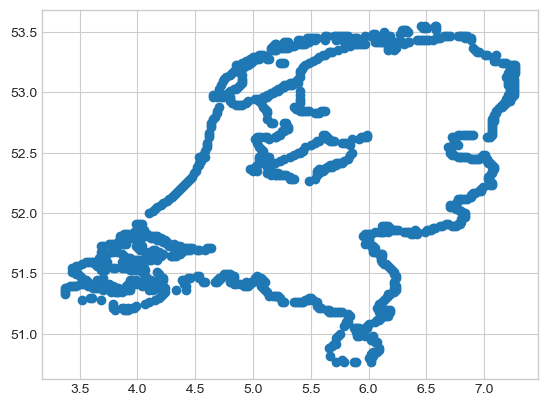

In [124]:
plt.scatter(missing["target_longitude"], missing["target_latitude"]) # Clearly boundary / coastal artifacts.
plt.show()

In [125]:
municipalities

,statcode,jrstatcode,statnaam,rubriek,id,geometry
0,GM0014,2025GM0014,Groningen,gemeente,1,"MULTIPOLYGON (((245269.7 592530.869, 245344.71..."
1,GM0034,2025GM0034,Almere,gemeente,2,"MULTIPOLYGON (((146891.056 493291.709, 147422...."
2,GM0037,2025GM0037,Stadskanaal,gemeente,3,"MULTIPOLYGON (((263763.866 566430.392, 263988...."
3,GM0047,2025GM0047,Veendam,gemeente,4,"MULTIPOLYGON (((256231.909 572319.213, 258595...."
4,GM0050,2025GM0050,Zeewolde,gemeente,5,"MULTIPOLYGON (((164905.825 488530.789, 165218...."
...,...,...,...,...,...,...
337,GM1979,2025GM1979,Eemsdelta,gemeente,338,"MULTIPOLYGON (((254210.03 603122.465, 254836.2..."
338,GM1980,2025GM1980,Dijk en Waard,gemeente,339,"MULTIPOLYGON (((114834.321 526066.026, 114919...."
339,GM1982,2025GM1982,Land van Cuijk,gemeente,340,"MULTIPOLYGON (((181384.076 418252.229, 182100 ..."
340,GM1991,2025GM1991,Maashorst,gemeente,341,"MULTIPOLYGON (((176672.671 418565.125, 176593...."


In [126]:
municipalities = municipalities.to_crs(targets_enriched.crs)

nearest = gpd.sjoin_nearest(
    missing,
    municipalities[["statnaam", "geometry"]],
    how="left",
    distance_col="dist_to_municipality_m"
)

nearest[["target_id", "population", "municipality", "dist_to_municipality_m"]].head(20)

,target_id,population,municipality,dist_to_municipality_m
0,target_population_0,3.116480,NaN,751.462783
2,target_population_2,10.389469,NaN,220.124734
4,target_population_4,6.779233,NaN,515.686837
5,target_population_5,11.197372,NaN,602.091170
6,target_population_6,14.626070,NaN,45.129507
7,target_population_7,15.869822,NaN,299.019426
8,target_population_8,6.099343,NaN,377.264558
9,target_population_9,12.311444,NaN,506.816812
10,target_population_10,1.730888,NaN,595.366371
11,target_population_11,3.974514,NaN,410.540952


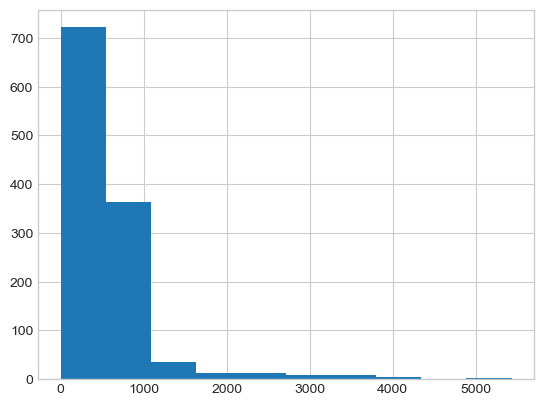

In [127]:
plt.hist(nearest["dist_to_municipality_m"])
plt.show()

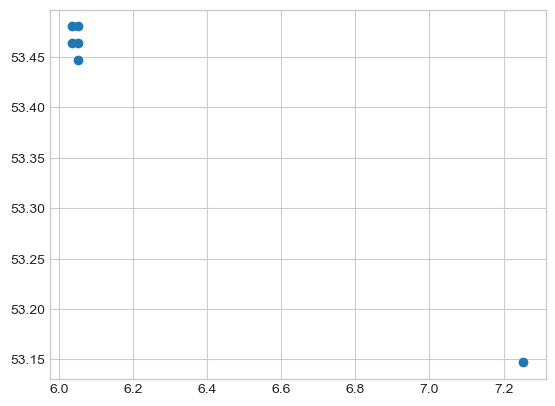

In [128]:
outliers = nearest[nearest["dist_to_municipality_m"]>4000]

plt.scatter(outliers["target_longitude"], outliers["target_latitude"])
plt.show()

In [129]:
outliers.head()

,target_id,target_longitude,target_latitude,population,geometry,municipality,province,corop_region,ggd_region,regioplus_region,zorgkantoor_region,woondeals_regions,roaz_regions,index_right,statnaam,dist_to_municipality_m
29,target_population_29,6.036250,53.480417,12.111441,POINT (198091.086 610664.854),NaN,NaN,NaN,NaN,NaN,NaN,Noordoost Friesland,NaN,12,Schiermonnikoog,5428.652523
30,target_population_30,6.052917,53.480417,11.261875,POINT (199197.595 610674.973),NaN,NaN,NaN,NaN,NaN,NaN,Noordoost Friesland,NaN,12,Schiermonnikoog,4327.940251
63,target_population_63,6.036250,53.463750,22.146314,POINT (198107.832 608809.911),NaN,NaN,NaN,NaN,NaN,NaN,Noordoost Friesland,NaN,6,Ameland,5096.797024
64,target_population_64,6.052917,53.463750,16.465350,POINT (199214.771 608820.033),NaN,NaN,NaN,NaN,NaN,NaN,Noordoost Friesland,NaN,12,Schiermonnikoog,4150.880052
107,target_population_107,6.052917,53.447083,12.189013,POINT (199231.945 606965.104),NaN,NaN,NaN,NaN,NaN,NaN,Noordoost Friesland,NaN,12,Schiermonnikoog,4508.860305


In [130]:
def fill_missing_by_nearest(
    enriched,
    boundary_gdf,
    value_col,
    output_col,
    max_distance_m=10000
):
    enriched = enriched.copy()
    boundary_gdf = boundary_gdf.to_crs(enriched.crs)

    missing_mask = enriched[output_col].isna()

    nearest = gpd.sjoin_nearest(
        enriched.loc[missing_mask],
        boundary_gdf[[value_col, "geometry"]],
        how="left",
        distance_col=f"{output_col}_nearest_distance_m"
    )

    valid = nearest[f"{output_col}_nearest_distance_m"] <= max_distance_m

    enriched.loc[nearest.index[valid], output_col] = nearest.loc[valid, value_col]
    enriched.loc[nearest.index, f"{output_col}_nearest_distance_m"] = nearest[
        f"{output_col}_nearest_distance_m"
    ]

    return enriched

In [138]:
##########              Fill in the missing value with the closest approximation via distance.

targets_enriched = fill_missing_by_nearest(
    targets_enriched,
    municipalities,
    value_col="statnaam",
    output_col="municipality",
    max_distance_m=10000
)

targets_enriched = fill_missing_by_nearest(
    targets_enriched,
    provinces,
    value_col="statnaam",
    output_col="province",
    max_distance_m=10000
)

targets_enriched = fill_missing_by_nearest(
    targets_enriched,
    corop_regions,
    value_col="statnaam",
    output_col="corop_region",
    max_distance_m=10000
)

targets_enriched = fill_missing_by_nearest(
    targets_enriched,
    ggd_regions,
    value_col="statnaam",
    output_col="ggd_region",
    max_distance_m=10000
)

targets_enriched = fill_missing_by_nearest(
    targets_enriched,
    regioplus_regions,
    value_col="statnaam",
    output_col="regioplus_region",
    max_distance_m=10000
)

targets_enriched = fill_missing_by_nearest(
    targets_enriched,
    zorgkantoor_regions,
    value_col="statnaam",
    output_col="zorgkantoor_region",
    max_distance_m=10000
)

targets_enriched = fill_missing_by_nearest(
    targets_enriched,
    woondeals_regions,
    value_col="regionale_woondeals",
    output_col="woondeals_regions",
    max_distance_m=10000
)

targets_enriched = fill_missing_by_nearest(
    targets_enriched,
    roaz_regions,
    value_col="rz_name",
    output_col="roaz_regions",
    max_distance_m=10000
)

targets_enriched = fill_missing_by_nearest(
    targets_enriched,
    veiligheids_regions,
    value_col="vr_name",
    output_col="veiligheids_regions",
    max_distance_m=10000
)

targets_enriched = fill_missing_by_nearest(
    targets_enriched,
    vng_zn_regions,
    value_col="zs_name",
    output_col="vng_zn_regions",
    max_distance_m=10000
)

In [140]:
targets_enriched.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 17896 entries, 0 to 17780
Data columns (total 25 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   target_id                               17896 non-null  str     
 1   target_longitude                        17896 non-null  float64 
 2   target_latitude                         17896 non-null  float64 
 3   population                              17896 non-null  float64 
 4   geometry                                17896 non-null  geometry
 5   municipality                            17896 non-null  str     
 6   province                                17896 non-null  str     
 7   corop_region                            17896 non-null  str     
 8   ggd_region                              17896 non-null  str     
 9   regioplus_region                        17896 non-null  str     
 10  zorgkantoor_region                      178

Now enrich the sources.

In [141]:
facilities_enriched = facilities_gdf.copy()



facilities_enriched = add_region_column(
    facilities_enriched,
    municipalities,
    region_name_col="statnaam",
    output_col="municipality"
)

facilities_enriched = add_region_column(
    facilities_enriched,
    provinces,
    region_name_col="statnaam",
    output_col="province"
)

facilities_enriched = add_region_column(
    facilities_enriched,
    corop_regions,
    region_name_col="statnaam",
    output_col="corop_region"
)

facilities_enriched = add_region_column(
    facilities_enriched,
    ggd_regions,
    region_name_col="statnaam",
    output_col="ggd_region"
)

facilities_enriched = add_region_column(
    facilities_enriched,
    regioplus_regions,
    region_name_col="statnaam",
    output_col="regioplus_region"
)

facilities_enriched = add_region_column(
    facilities_enriched,
    zorgkantoor_regions,
    region_name_col="statnaam",
    output_col="zorgkantoor_region"
)

facilities_enriched = add_region_column(
    facilities_enriched,
    woondeals_regions,
    region_name_col="regionale_woondeals",
    output_col="woondeals_regions"
)

facilities_enriched = add_region_column(
    facilities_enriched,
    roaz_regions,
    region_name_col="rz_name",
    output_col="roaz_regions"
)

facilities_enriched = add_region_column(
    facilities_enriched,
    veiligheids_regions,
    region_name_col="vr_name",
    output_col="veiligheids_regions"
)

facilities_enriched = add_region_column(
    facilities_enriched,
    vng_zn_regions,
    region_name_col="zs_name",
    output_col="vng_zn_regions"
)

In [142]:
facilities_enriched.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 2549 entries, 0 to 2540
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   source_id            2549 non-null   str     
 1   source_longitude     2549 non-null   float64 
 2   source_latitude      2549 non-null   float64 
 3   dist_snap_source     2549 non-null   float64 
 4   facility_id          2549 non-null   str     
 5   facility_name        2549 non-null   str     
 6   layer                2549 non-null   str     
 7   analysis_layer       2549 non-null   str     
 8   source               2549 non-null   str     
 9   source_detail        2549 non-null   str     
 10  amenity              2330 non-null   str     
 11  healthcare           2143 non-null   str     
 12  city                 2127 non-null   str     
 13  postcode             2015 non-null   str     
 14  geometry             2549 non-null   geometry
 15  municipality      

In [60]:
missing_facilities = facilities_enriched[facilities_enriched["municipality"].isna()].copy()

missing_facilities[["source_id", "source_longitude", "source_latitude", "geometry"]].head()

,source_id,source_longitude,source_latitude,geometry
67,source_table_osm:way:367107495,4.464297,51.470979,POINT (4.4643 51.47098)


In [61]:
municipalities_facilities = municipalities.to_crs(facilities_enriched.crs)

nearest_facilities = gpd.sjoin_nearest(
    missing_facilities,
    municipalities_facilities[["statnaam", "geometry"]],
    how="left",
    distance_col="dist_to_municipality_m"
)

nearest_facilities[["source_id", "municipality", "dist_to_municipality_m"]].head(20)

c:\Users\johne\anaconda3\envs\pisa_geo312\Lib\site-packages\geopandas\array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,source_id,municipality,dist_to_municipality_m
67,source_table_osm:way:367107495,NaN,0.000125


In [143]:
##########              Fill in the missing value with the closest approximation via distance.

facilities_enriched = fill_missing_by_nearest(
    facilities_enriched,
    municipalities,
    value_col="statnaam",
    output_col="municipality",
    max_distance_m=10000
)

facilities_enriched = fill_missing_by_nearest(
    facilities_enriched,
    provinces,
    value_col="statnaam",
    output_col="province",
    max_distance_m=10000
)

facilities_enriched = fill_missing_by_nearest(
    facilities_enriched,
    corop_regions,
    value_col="statnaam",
    output_col="corop_region",
    max_distance_m=10000
)

facilities_enriched = fill_missing_by_nearest(
    facilities_enriched,
    ggd_regions,
    value_col="statnaam",
    output_col="ggd_region",
    max_distance_m=10000
)

facilities_enriched = fill_missing_by_nearest(
    facilities_enriched,
    regioplus_regions,
    value_col="statnaam",
    output_col="regioplus_region",
    max_distance_m=10000
)

facilities_enriched = fill_missing_by_nearest(
    facilities_enriched,
    zorgkantoor_regions,
    value_col="statnaam",
    output_col="zorgkantoor_region",
    max_distance_m=10000
)

facilities_enriched = fill_missing_by_nearest(
    facilities_enriched,
    woondeals_regions,
    value_col="regionale_woondeals",
    output_col="woondeals_regions",
    max_distance_m=10000
)

facilities_enriched = fill_missing_by_nearest(
    facilities_enriched,
    roaz_regions,
    value_col="rz_name",
    output_col="roaz_regions",
    max_distance_m=10000
)

facilities_enriched = fill_missing_by_nearest(
    facilities_enriched,
    veiligheids_regions,
    value_col="vr_name",
    output_col="veiligheids_regions",
    max_distance_m=10000
)

facilities_enriched = fill_missing_by_nearest(
    facilities_enriched,
    vng_zn_regions,
    value_col="zs_name",
    output_col="vng_zn_regions",
    max_distance_m=10000
)

c:\Users\johne\anaconda3\envs\pisa_geo312\Lib\site-packages\geopandas\array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(
c:\Users\johne\anaconda3\envs\pisa_geo312\Lib\site-packages\geopandas\array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(
c:\Users\johne\anaconda3\envs\pisa_geo312\Lib\site-packages\geopandas\array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(
c:\Users\johne\anaconda3\envs\pisa_geo312\Lib\site-packages\geopandas\array.py:411: UserWarning: Geometry is in a geographic CR

In [144]:
facilities_enriched.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 2549 entries, 0 to 2540
Data columns (total 35 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   source_id                               2549 non-null   str     
 1   source_longitude                        2549 non-null   float64 
 2   source_latitude                         2549 non-null   float64 
 3   dist_snap_source                        2549 non-null   float64 
 4   facility_id                             2549 non-null   str     
 5   facility_name                           2549 non-null   str     
 6   layer                                   2549 non-null   str     
 7   analysis_layer                          2549 non-null   str     
 8   source                                  2549 non-null   str     
 9   source_detail                           2549 non-null   str     
 10  amenity                                 2330 

In [145]:
facilities_enriched.iloc[67,:] # One general practitioner in West-Noord-Brabant was presenting trouble when locking to an administrative region.
# It turns out that this is explicitly a border care hospital

source_id                                                    source_table_osm:way:367107495
source_longitude                                                                   4.464297
source_latitude                                                                   51.470979
dist_snap_source                                                                  21.836562
facility_id                                                               osm:way:367107495
facility_name                                       AZ Klina Zorgpunt Grens / Kind en Gezin
layer                                                                  general_practitioner
analysis_layer                                                                      layer_3
source                                                       OpenStreetMap via Overpass API
source_detail                             OSM tags: amenity=doctors OR healthcare=doctor...
amenity                                                                         

# Now we have our enhanced targets and sources data with the appropriate adminstrative classifications.

We can then combine this all with appropriate Regiobeeld data.

Let's load and clean the Regiobeeld data.

In [65]:
PATH = Path(r"c:/Users/johne/OneDrive - UvA/Documents/Professional/University of Amsterdam/Master's Thesis/MSc_Thesis_Healthcare_Accessibility/Public-Infrastructure-Service-Access/Research-Sandbox/Master_Theses/DSBA_2025_2026/Jack Martin")

PATH_DATA = PATH / "data"

dims = dict()
meta = dict()
fact = dict()

RIVM_Cijfersoort_dims = pd.read_csv(PATH_DATA / "50148NED_RIVM_dims_Cijfersoort.csv")
dims["Cijfersoort"] = RIVM_Cijfersoort_dims
RIVM_Perioden_dims = pd.read_csv(PATH_DATA / "50148NED_RIVM_dims_Perioden.csv")
dims["Perioden"] = RIVM_Perioden_dims
RIVM_RegioS_dims = pd.read_csv(PATH_DATA / "50148NED_RIVM_dims_RegioS.csv")
dims["RegioS"] = RIVM_RegioS_dims
RIVM_CategoryGroups_meta = pd.read_csv(PATH_DATA / "50148NED_RIVM_meta_CategoryGroups.csv")
meta["Category_Groups"] = RIVM_CategoryGroups
RIVM_Cijfersoort_meta = pd.read_csv(PATH_DATA / "50148NED_RIVM_meta_Cijfersoort.csv")
meta["Cijfersoort"] = RIVM_Cijfersoort_meta
RIVM_DataProperties_meta = pd.read_csv(PATH_DATA / "50148NED_RIVM_meta_DataProperties.csv")
meta["Data_Properties"] = RIVM_DataProperties
RIVM_Perioden_meta = pd.read_csv(PATH_DATA / "50148NED_RIVM_meta_Perioden.csv")
meta["Perioden"] = RIVM_Perioden_meta
RIVM_RegioS_meta = pd.read_csv(PATH_DATA / "50148NED_RIVM_meta_RegioS.csv")
meta["RegioS"] = RIVM_RegioS_meta
RIVM_TableInfos_meta = pd.read_csv(PATH_DATA / "50148NED_RIVM_meta_TableInfos.csv")
meta["TableInfos"] = RIVM_TableInfos_meta
RIVM_RIVM = pd.read_csv(PATH_DATA / "50148NED_RIVM.csv")
fact["RIVM"] = RIVM_RIVM

In [66]:
# Dimension Tables Examination

print("Examining Dimension Tables", "\n\n")

for idx, table in enumerate(dims):
    print(f"Examining {table} Dimension Table")
    display(dims[table].info())
    display(dims[table].head())
    print("\n\n")


Examining Dimension Tables 


Examining Cijfersoort Dimension Table
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       6 non-null      int64  
 1   Key              6 non-null      str    
 2   Title            6 non-null      str    
 3   Description      0 non-null      float64
 4   CategoryGroupID  0 non-null      float64
dtypes: float64(2), int64(1), str(2)
memory usage: 479.0 bytes


None

,Unnamed: 0,Key,Title,Description,CategoryGroupID
0,0,aantal,Aantal,NaN,NaN
1,1,per_1e4,Aantal per 10.000,NaN,NaN
2,2,percentage,Percentage,NaN,NaN
3,3,score,Score,NaN,NaN
4,4,index,Index,NaN,NaN





Examining Perioden Dimension Table
<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   45 non-null     int64  
 1   Key          45 non-null     str    
 2   Title        45 non-null     str    
 3   Description  0 non-null      float64
 4   Status       45 non-null     str    
dtypes: float64(1), int64(1), str(3)
memory usage: 2.9 KB


None

,Unnamed: 0,Key,Title,Description,Status
0,0,1999JJ00,1999,NaN,Definitief
1,1,2000JJ00,2000,NaN,Definitief
2,2,2001JJ00,2001,NaN,Definitief
3,3,2002JJ00,2002,NaN,Definitief
4,4,2003JJ00,2003,NaN,Definitief





Examining RegioS Dimension Table
<class 'pandas.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Unnamed: 0       599 non-null    int64
 1   Key              599 non-null    str  
 2   Title            599 non-null    str  
 3   Description      598 non-null    str  
 4   CategoryGroupID  599 non-null    int64
dtypes: int64(2), str(3)
memory usage: 163.0 KB


None

,Unnamed: 0,Key,Title,Description,CategoryGroupID
0,0,NL01,Nederland,NaN,1
1,1,PV20,Groningen (PV),PV = Provincie\r\n\r\nBestuurlijke onderverdel...,2
2,2,PV21,Fryslân (PV),PV = Provincie\r\n\r\nBestuurlijke onderverdel...,2
3,3,PV22,Drenthe (PV),PV = Provincie\r\n\r\nBestuurlijke onderverdel...,2
4,4,PV23,Overijssel (PV),PV = Provincie\r\n\r\nBestuurlijke onderverdel...,2


In [67]:
# Meta Tables Examination

print("Examining Meta Tables", "\n\n")

for idx, table in enumerate(meta):
    print(f"Examining {table} Meta Table")
    display(meta[table].info())
    display(meta[table].head())
    print("\n\n")


Examining Meta Tables 


Examining Category_Groups Meta Table
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    13 non-null     int64  
 1   ID            13 non-null     int64  
 2   DimensionKey  13 non-null     str    
 3   Title         13 non-null     str    
 4   Description   2 non-null      str    
 5   ParentID      11 non-null     float64
dtypes: float64(1), int64(2), str(3)
memory usage: 1.2 KB


None

,Unnamed: 0,ID,DimensionKey,Title,Description,ParentID
0,0,0,RegioS,Regiototalen,Totalen van de verschillende regionale indelin...,NaN
1,1,1,RegioS,Nederland,NaN,0.0
2,2,2,RegioS,Provincies,NaN,0.0
3,3,3,RegioS,COROP-gebieden,NaN,0.0
4,4,4,RegioS,GGD-regio's,NaN,0.0





Examining Cijfersoort Meta Table
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       6 non-null      int64  
 1   Key              6 non-null      str    
 2   Title            6 non-null      str    
 3   Description      0 non-null      float64
 4   CategoryGroupID  0 non-null      float64
dtypes: float64(2), int64(1), str(2)
memory usage: 479.0 bytes


None

...

None

,Unnamed: 0,Key,Title,Description,CategoryGroupID
0,0,NL01,Nederland,NaN,1
1,1,PV20,Groningen (PV),PV = Provincie\r\n\r\nBestuurlijke onderverdel...,2
2,2,PV21,Fryslân (PV),PV = Provincie\r\n\r\nBestuurlijke onderverdel...,2
3,3,PV22,Drenthe (PV),PV = Provincie\r\n\r\nBestuurlijke onderverdel...,2
4,4,PV23,Overijssel (PV),PV = Provincie\r\n\r\nBestuurlijke onderverdel...,2





Examining TableInfos Meta Table
<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1 non-null      int64  
 1   ID                   1 non-null      int64  
 2   Title                1 non-null      str    
 3   ShortTitle           1 non-null      str    
 4   Identifier           1 non-null      str    
 5   Summary              1 non-null      str    
 6   Modified             1 non-null      str    
 7   ReasonDelivery       1 non-null      str    
 8   ExplanatoryText      0 non-null      float64
 9   Language             1 non-null      str    
 10  Catalog              1 non-null      str    
 11  Frequency            1 non-null      str    
 12  Period               1 non-null      str    
 13  ShortDescription     1 non-null      str    
 14  Description          1 non-null      str    
 15  DefaultPresentation 

None

,Unnamed: 0,ID,Title,ShortTitle,Identifier,Summary,Modified,ReasonDelivery,ExplanatoryText,Language,...,Period,ShortDescription,Description,DefaultPresentation,DefaultSelection,GraphTypes,OutputStatus,Source,MetaDataModified,SearchPriority
0,0,0,"RIVM Regiobeeld; regio (indeling 2024), 1999-2040",RIVM Regiobeeld; regio (indeling 2024),50148NED,"Bevolking, gezondheid, leefstijl, zorggebruik,...",2025-11-11T02:00:00,Nieuw,NaN,nl,...,1999-2040,\nDe cijfers in deze tabel zijn gebaseerd op v...,INHOUDSOPGAVE\r\n\r\n1. Toelichting\r\n2. Defi...,"ts=1762504947778&graphtype=Table&r=Topics,Cijf...",$filter=((RegioS eq 'NL01 ') or (RegioS eq 'P...,"Table,Bar,Line",Regulier,Regiobeeld.nl; Rijksinstituut voor Volksgezond...,2025-11-11T02:00:00,2


In [68]:
# Take a closer look at the Data Properties table.

display(meta["Data_Properties"].info())
display(meta["Data_Properties"].head())
for col in meta["Data_Properties"].columns.to_list():
    print("Unique values of indicators")
    display(meta["Data_Properties"][col].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 1949 entries, 0 to 1948
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     1949 non-null   int64  
 1   odata.type     1949 non-null   str    
 2   ID             1949 non-null   int64  
 3   Position       1889 non-null   float64
 4   ParentID       1931 non-null   float64
 5   Type           1949 non-null   str    
 6   Key            1889 non-null   str    
 7   Title          1949 non-null   str    
 8   Description    1831 non-null   str    
 9   ReleasePolicy  1 non-null      object 
 10  Datatype       1886 non-null   str    
 11  Unit           0 non-null      float64
 12  Decimals       1886 non-null   float64
 13  Default        1886 non-null   str    
dtypes: float64(4), int64(2), object(1), str(7)
memory usage: 656.0+ KB


None

,Unnamed: 0,odata.type,ID,Position,ParentID,Type,Key,Title,Description,ReleasePolicy,Datatype,Unit,Decimals,Default
0,0,Cbs.OData.Dimension,0,0.0,NaN,Dimension,Cijfersoort,Cijfersoort,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Cbs.OData.Dimension,1,1.0,NaN,Dimension,RegioS,Regio's,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Cbs.OData.TimeDimension,2,2.0,NaN,TimeDimension,Perioden,Perioden,NaN,False,NaN,NaN,NaN,NaN
3,3,Cbs.OData.TopicGroup,3,NaN,NaN,TopicGroup,NaN,Acute zorg,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Cbs.OData.TopicGroup,4,NaN,3.0,TopicGroup,NaN,Overig,NaN,NaN,NaN,NaN,NaN,NaN


Unique values of indicators


Unnamed: 0
0       1
1       1
2       1
3       1
4       1
       ..
1944    1
1945    1
1946    1
1947    1
1948    1
Name: count, Length: 1949, dtype: int64

...

Series([], Name: count, dtype: int64)

Unique values of indicators


Decimals
1.0    1363
0.0     522
3.0       1
Name: count, dtype: int64

Unique values of indicators


Default
Missing    1886
Name: count, dtype: int64

In [69]:
#   What are the different topic groups in the Data Properties?

display(meta["Data_Properties"]["Type"].value_counts())

Type
Topic            1886
TopicGroup         60
Dimension           2
TimeDimension       1
Name: count, dtype: int64

In [70]:
RIVM_RIVM.head()

,ID,Cijfersoort,RegioS,Perioden,Amb1A1_1,Amb1A2_2,Cap1Moe1Amb2_3,Cap1Moe1Ic1_4,Cap1Moe1Ic2_5,Cap1Moe1Ic3_6,...,Chr2PrevLongkanker09j_1877,Chr2PrevLongkanker1019j_1878,Chr2PrevLongkanker2029j_1879,Chr2PrevLongkanker3039j_1880,Chr2PrevLongkanker4049j_1881,Chr2PrevLongkanker5059j_1882,Chr2PrevLongkanker6069j_1883,Chr2PrevLongkanker7079j_1884,Chr2PrevLongkanker80_1885,GgzZvwInciZor5Aa6_1886
0,0,aantal,NL01,1999JJ00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,aantal,NL01,2000JJ00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,aantal,NL01,2001JJ00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,aantal,NL01,2002JJ00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,aantal,NL01,2003JJ00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
Enhanced_Fact_Table = RIVM_RIVM.copy()

Cijfersoort_replaced = Enhanced_Fact_Table["Cijfersoort"].replace(dims["Cijfersoort"]["Key"].to_list(), dims["Cijfersoort"]["Title"].to_list())

Perioden_replaced = Enhanced_Fact_Table["Perioden"].replace(dims["Perioden"]["Key"].to_list(), dims["Perioden"]["Title"].to_list())

Regios_replaced = Enhanced_Fact_Table["RegioS"].replace(dims["RegioS"]["Key"].to_list(), dims["RegioS"]["Title"].to_list())

Enhanced_Fact_Table["Number Type"] = Cijfersoort_replaced
Enhanced_Fact_Table["Period"] = Perioden_replaced
Enhanced_Fact_Table["Region"] = Regios_replaced

# Reorder the columns properly:

# First columns:

First_columns = ["ID", "Cijfersoort", "Number Type", "RegioS", "Region", "Perioden", "Period"]

Other_columns = [col for col in Enhanced_Fact_Table.columns.to_list() if col not in First_columns and col not in ["Unnamed: 0"]]

ordered_columns = First_columns + Other_columns

Enhanced_Fact_Table = Enhanced_Fact_Table[ordered_columns]

Enhanced_Fact_Table.head()

,ID,Cijfersoort,Number Type,RegioS,Region,Perioden,Period,Amb1A1_1,Amb1A2_2,Cap1Moe1Amb2_3,...,Chr2PrevLongkanker09j_1877,Chr2PrevLongkanker1019j_1878,Chr2PrevLongkanker2029j_1879,Chr2PrevLongkanker3039j_1880,Chr2PrevLongkanker4049j_1881,Chr2PrevLongkanker5059j_1882,Chr2PrevLongkanker6069j_1883,Chr2PrevLongkanker7079j_1884,Chr2PrevLongkanker80_1885,GgzZvwInciZor5Aa6_1886
0,0,aantal,Aantal,NL01,Nederland,1999JJ00,1999,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,aantal,Aantal,NL01,Nederland,2000JJ00,2000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,aantal,Aantal,NL01,Nederland,2001JJ00,2001,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,aantal,Aantal,NL01,Nederland,2002JJ00,2002,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,aantal,Aantal,NL01,Nederland,2003JJ00,2003,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
Enhanced_Fact_Table[Enhanced_Fact_Table["Region"] == "Amsterdam"][Enhanced_Fact_Table["Period"] == "2025"].iloc[0].dropna()

C:\Users\johne\AppData\Local\Temp\ipykernel_62640\2546504649.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Enhanced_Fact_Table[Enhanced_Fact_Table["Region"] == "Amsterdam"][Enhanced_Fact_Table["Period"] == "2025"].iloc[0].dropna()


ID                              3086
Cijfersoort               aantal    
Number Type                   Aantal
RegioS                        GM0363
Region                     Amsterdam
                             ...    
JeugdzorgJeu4Jon1_1485       20920.0
JeugdzorgJeu5Jeu2_1486       29510.0
JeugdzorgJeu5Jon1_1487       19880.0
JeugdzorgJeu6Jeu2_1488         920.0
JeugdzorgJeu6Jon1_1489         620.0
Name: 3086, Length: 118, dtype: object

In [73]:
meta["Data_Properties"]["Description"]

0                                                     NaN
1                                                     NaN
2                                                     NaN
3                                                     NaN
4                                                     NaN
                              ...                        
1944    Aantal personen met longkanker in de leeftijd ...
1945    Aantal personen met longkanker in de leeftijd ...
1946    Aantal personen met longkanker in de leeftijd ...
1947    Aantal personen met longkanker in de leeftijd ...
1948    Incidentie zorgprofiel B (GGZ in de Wlz) in de...
Name: Description, Length: 1949, dtype: str

In [74]:
meta["Data_Properties"][meta["Data_Properties"]["Key"].str.contains("JeugdzorgJeu4Jon1_1485")]["Description"].item()

'Jongeren met jeugdzorg in de vorm van jeugdhulp (in natura) totaal\r\n\r\nBron: Beleidsinformatie Jeugd, CBS (via CBS Remote Access), bewerking en projecties RIVM'

In [75]:
meta["Data_Properties"].info()

<class 'pandas.DataFrame'>
RangeIndex: 1949 entries, 0 to 1948
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     1949 non-null   int64  
 1   odata.type     1949 non-null   str    
 2   ID             1949 non-null   int64  
 3   Position       1889 non-null   float64
 4   ParentID       1931 non-null   float64
 5   Type           1949 non-null   str    
 6   Key            1889 non-null   str    
 7   Title          1949 non-null   str    
 8   Description    1831 non-null   str    
 9   ReleasePolicy  1 non-null      object 
 10  Datatype       1886 non-null   str    
 11  Unit           0 non-null      float64
 12  Decimals       1886 non-null   float64
 13  Default        1886 non-null   str    
dtypes: float64(4), int64(2), object(1), str(7)
memory usage: 656.0+ KB


In [76]:
Enhanced_Fact_Table.head()

,ID,Cijfersoort,Number Type,RegioS,Region,Perioden,Period,Amb1A1_1,Amb1A2_2,Cap1Moe1Amb2_3,...,Chr2PrevLongkanker09j_1877,Chr2PrevLongkanker1019j_1878,Chr2PrevLongkanker2029j_1879,Chr2PrevLongkanker3039j_1880,Chr2PrevLongkanker4049j_1881,Chr2PrevLongkanker5059j_1882,Chr2PrevLongkanker6069j_1883,Chr2PrevLongkanker7079j_1884,Chr2PrevLongkanker80_1885,GgzZvwInciZor5Aa6_1886
0,0,aantal,Aantal,NL01,Nederland,1999JJ00,1999,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,aantal,Aantal,NL01,Nederland,2000JJ00,2000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,aantal,Aantal,NL01,Nederland,2001JJ00,2001,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,aantal,Aantal,NL01,Nederland,2002JJ00,2002,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,aantal,Aantal,NL01,Nederland,2003JJ00,2003,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
dims["RegioS"][dims["RegioS"]["Title"] == "Amsterdam"]

,Unnamed: 0,Key,Title,Description,CategoryGroupID
68,68,GM0363,Amsterdam,Gemeentelijke herindeling per 24-03-2022\r\nBe...,12
552,552,ZS03,Amsterdam,ZS = VNG/ZN regio. De Vereniging van Nederland...,8


In [78]:
meta["Data_Properties"][meta["Data_Properties"]["Type"]=="TopicGroup"]

,Unnamed: 0,odata.type,ID,Position,ParentID,Type,Key,Title,Description,ReleasePolicy,Datatype,Unit,Decimals,Default
3,3,Cbs.OData.TopicGroup,3,NaN,NaN,TopicGroup,NaN,Acute zorg,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Cbs.OData.TopicGroup,4,NaN,3.0,TopicGroup,NaN,Overig,NaN,NaN,NaN,NaN,NaN,NaN
52,52,Cbs.OData.TopicGroup,52,NaN,NaN,TopicGroup,NaN,Bevolkingsontwikkeling,NaN,NaN,NaN,NaN,NaN,NaN
53,53,Cbs.OData.TopicGroup,53,NaN,52.0,TopicGroup,NaN,Geboorten,NaN,NaN,NaN,NaN,NaN,NaN
55,55,Cbs.OData.TopicGroup,55,NaN,52.0,TopicGroup,NaN,Huishoudens,NaN,NaN,NaN,NaN,NaN,NaN
62,62,Cbs.OData.TopicGroup,62,NaN,52.0,TopicGroup,NaN,Leeftijdsopbouw en levensverwachting,NaN,NaN,NaN,NaN,NaN,NaN
76,76,Cbs.OData.TopicGroup,76,NaN,52.0,TopicGroup,NaN,Totale bevolking,NaN,NaN,NaN,NaN,NaN,NaN
78,78,Cbs.OData.TopicGroup,78,NaN,NaN,TopicGroup,NaN,GALA,NaN,NaN,NaN,NaN,NaN,NaN
79,79,Cbs.OData.TopicGroup,79,NaN,78.0,TopicGroup,NaN,Aanpak Overgewicht en Obesitas Kinderen,NaN,NaN,NaN,NaN,NaN,NaN
82,82,Cbs.OData.TopicGroup,82,NaN,78.0,TopicGroup,NaN,Gecombineerde Leefstijlinterventie,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
DP = meta["Data_Properties"]

TopicGroups = dict()

TopicGroups["Acute zorg"] = {
    "Overig": DP[DP["ParentID"] == 4],
    "Unassigned": DP[DP["ParentID"] == 3],
}

TopicGroups["Bevolkingsontwikkeling"] = {
    "Geboorten": DP[DP["ParentID"] == 53],
    "Huishoudens": DP[DP["ParentID"] == 55],
    "Leeftijdsopbouw en levensverwachting": DP[DP["ParentID"] == 62],
    "Totale bevolking": DP[DP["ParentID"] == 76],
    "Unassigned": DP[DP["ParentID"] == 52],
}

TopicGroups["GALA"] = {
    "Aanpak Overgewicht en Obesitas Kinderen": DP[DP["ParentID"] == 79],
    "Gecombineerde Leefstijlinterventie": DP[DP["ParentID"] == 82],
    "Kansrijke Start": DP[DP["ParentID"] == 85],
    "Procesindicatoren": DP[DP["ParentID"] == 88],
    "Sociaal Verwijzen": DP[DP["ParentID"] == 92],
    "Uitkomstindicatoren": DP[DP["ParentID"] == 95],
    "Valpreventie": DP[DP["ParentID"] == 98],
    "Unassigned": DP[DP["ParentID"] == 78],
}

TopicGroups["Gezondheid en leefstijl"] = {
    "(Ervaren) Gezondheid": DP[DP["ParentID"] == 102],
    "Leefstijlindicatoren": DP[DP["ParentID"] == 116],
    "Unassigned": DP[DP["ParentID"] == 101],
}

TopicGroups["Leefomgeving"] = {
    "Fysieke omgeving": DP[DP["ParentID"] == 136],
    "Sociaal-economische omgeving": DP[DP["ParentID"] == 161],
    "Sociale omgeving": DP[DP["ParentID"] == 169],
    "Unassigned": DP[DP["ParentID"] == 135],
}

TopicGroups["Monitor doelgroepen IZA"] = {
    "Mensen met (risico op) hart- en vaatziekten": DP[DP["ParentID"] == 176],
    "Mensen met (risico op) kanker": DP[DP["ParentID"] == 352],
    "Mensen met beperkte gezondheidsvaardigheden": DP[DP["ParentID"] == 686],
    "Mensen met psychische problematiek": DP[DP["ParentID"] == 713],
    "Ouderen met een kwetsbare gezondheid": DP[DP["ParentID"] == 875],
    "Unassigned": DP[DP["ParentID"] == 175],
}

TopicGroups["Overig"] = {
    "Overig": DP[DP["ParentID"] == 953],
    "Unassigned": DP[DP["ParentID"] == 952],
}

TopicGroups["Psychische problematiek"] = {
    "Demografische inzichten": DP[DP["ParentID"] == 960],
    "Intensieve klinische behandeling": DP[DP["ParentID"] == 974],
    "Langdurige (intensieve) woonzorg": DP[DP["ParentID"] == 979],
    "Leefklimaat": DP[DP["ParentID"] == 1000],
    "Mentale gezondheid": DP[DP["ParentID"] == 1003],
    "Sociaaleconomische status": DP[DP["ParentID"] == 1005],
    "Wachttijden en wachtenden": DP[DP["ParentID"] == 1017],
    "Werk en inkomen": DP[DP["ParentID"] == 1132],
    "Unassigned": DP[DP["ParentID"] == 959],
}

TopicGroups["Sociaal verwijzen"] = {
    "Samenwerking": DP[DP["ParentID"] == 1137],
    "Uitvoering": DP[DP["ParentID"] == 1143],
    "Werkwijze": DP[DP["ParentID"] == 1147],
    "Unassigned": DP[DP["ParentID"] == 1136],
}

TopicGroups["Verantwoording"] = {
    "Unassigned": DP[DP["ParentID"] == 1150],
}

TopicGroups["Verpleegzorgraming"] = {
    "Overig": DP[DP["ParentID"] == 1183],
    "Unassigned": DP[DP["ParentID"] == 1182],
}

TopicGroups["Zorgaanbod en arbeidsmarkt"] = {
    "Eerstelijns zorg": DP[DP["ParentID"] == 1227],
    "Informele zorg": DP[DP["ParentID"] == 1233],
    "Overig": DP[DP["ParentID"] == 1235],
    "Unassigned": DP[DP["ParentID"] == 1226],
}

TopicGroups["Zorggebruik"] = {
    "Eerstelijnszorg": DP[DP["ParentID"] == 1257],
    "Geestelijke gezondheidszorg": DP[DP["ParentID"] == 1319],
    "Langdurige zorg": DP[DP["ParentID"] == 1396],
    "Medisch specialistische zorg": DP[DP["ParentID"] == 1407],
    "Sociaal domein": DP[DP["ParentID"] == 1528],
    "Zorg rond de geboorte": DP[DP["ParentID"] == 1554],
    "Zorgkosten": DP[DP["ParentID"] == 1561],
    "Unassigned": DP[DP["ParentID"] == 1256],
}

TopicGroups["Zorggebruik bij chronische aandoeningen"] = {
    "Overig": DP[DP["ParentID"] == 1595],
    "Unassigned": DP[DP["ParentID"] == 1594],
}

In [80]:
TopicGroups_EN = dict()

TopicGroups_EN["Acute care"] = {
    "Other": DP[DP["ParentID"] == 4],
    "Unassigned": DP[DP["ParentID"] == 3],
}

TopicGroups_EN["Population development"] = {
    "Births": DP[DP["ParentID"] == 53],
    "Households": DP[DP["ParentID"] == 55],
    "Age structure and life expectancy": DP[DP["ParentID"] == 62],
    "Total population": DP[DP["ParentID"] == 76],
    "Unassigned": DP[DP["ParentID"] == 52],
}

TopicGroups_EN["GALA"] = {
    "Child overweight and obesity approach": DP[DP["ParentID"] == 79],
    "Combined lifestyle intervention": DP[DP["ParentID"] == 82],
    "Promising Start": DP[DP["ParentID"] == 85],
    "Process indicators": DP[DP["ParentID"] == 88],
    "Social prescribing": DP[DP["ParentID"] == 92],
    "Outcome indicators": DP[DP["ParentID"] == 95],
    "Fall prevention": DP[DP["ParentID"] == 98],
    "Unassigned": DP[DP["ParentID"] == 78],
}

TopicGroups_EN["Health and lifestyle"] = {
    "Self-perceived health": DP[DP["ParentID"] == 102],
    "Lifestyle indicators": DP[DP["ParentID"] == 116],
    "Unassigned": DP[DP["ParentID"] == 101],
}

TopicGroups_EN["Living environment"] = {
    "Physical environment": DP[DP["ParentID"] == 136],
    "Socioeconomic environment": DP[DP["ParentID"] == 161],
    "Social environment": DP[DP["ParentID"] == 169],
    "Unassigned": DP[DP["ParentID"] == 135],
}

TopicGroups_EN["IZA target group monitor"] = {
    "People with or at risk of cardiovascular disease": DP[DP["ParentID"] == 176],
    "People with or at risk of cancer": DP[DP["ParentID"] == 352],
    "People with limited health literacy": DP[DP["ParentID"] == 686],
    "People with mental health problems": DP[DP["ParentID"] == 713],
    "Older people with vulnerable health": DP[DP["ParentID"] == 875],
    "Unassigned": DP[DP["ParentID"] == 175],
}

TopicGroups_EN["Other"] = {
    "Other": DP[DP["ParentID"] == 953],
    "Unassigned": DP[DP["ParentID"] == 952],
}

TopicGroups_EN["Mental health problems"] = {
    "Demographic insights": DP[DP["ParentID"] == 960],
    "Intensive clinical treatment": DP[DP["ParentID"] == 974],
    "Long-term intensive residential care": DP[DP["ParentID"] == 979],
    "Living climate": DP[DP["ParentID"] == 1000],
    "Mental health": DP[DP["ParentID"] == 1003],
    "Socioeconomic status": DP[DP["ParentID"] == 1005],
    "Waiting times and people waiting": DP[DP["ParentID"] == 1017],
    "Work and income": DP[DP["ParentID"] == 1132],
    "Unassigned": DP[DP["ParentID"] == 959],
}

TopicGroups_EN["Social prescribing"] = {
    "Collaboration": DP[DP["ParentID"] == 1137],
    "Implementation": DP[DP["ParentID"] == 1143],
    "Working method": DP[DP["ParentID"] == 1147],
    "Unassigned": DP[DP["ParentID"] == 1136],
}

TopicGroups_EN["Accountability"] = {
    "Unassigned": DP[DP["ParentID"] == 1150],
}

TopicGroups_EN["Nursing care forecast"] = {
    "Other": DP[DP["ParentID"] == 1183],
    "Unassigned": DP[DP["ParentID"] == 1182],
}

TopicGroups_EN["Care supply and labour market"] = {
    "Primary care": DP[DP["ParentID"] == 1227],
    "Informal care": DP[DP["ParentID"] == 1233],
    "Other": DP[DP["ParentID"] == 1235],
    "Unassigned": DP[DP["ParentID"] == 1226],
}

TopicGroups_EN["Care use"] = {
    "Primary care": DP[DP["ParentID"] == 1257],
    "Mental healthcare": DP[DP["ParentID"] == 1319],
    "Long-term care": DP[DP["ParentID"] == 1396],
    "Medical specialist care": DP[DP["ParentID"] == 1407],
    "Social domain": DP[DP["ParentID"] == 1528],
    "Birth care": DP[DP["ParentID"] == 1554],
    "Care costs": DP[DP["ParentID"] == 1561],
    "Unassigned": DP[DP["ParentID"] == 1256],
}

TopicGroups_EN["Care use among people with chronic conditions"] = {
    "Other": DP[DP["ParentID"] == 1595],
    "Unassigned": DP[DP["ParentID"] == 1594],
}

In [81]:
# Test out the topic Groups

TopicGroups_EN["Acute care"]["Other"]

,Unnamed: 0,odata.type,ID,Position,ParentID,Type,Key,Title,Description,ReleasePolicy,Datatype,Unit,Decimals,Default
5,5,Cbs.OData.Topic,5,3.0,4.0,Topic,Amb1A1_1,amb1:a1,Aantal minuten waarin 95% van ambulance-inzett...,NaN,Double,NaN,1.0,Missing
6,6,Cbs.OData.Topic,6,4.0,4.0,Topic,Amb1A2_2,amb1:a2,Aantal minuten waarin 95% van ambulance-inzett...,NaN,Double,NaN,1.0,Missing
7,7,Cbs.OData.Topic,7,5.0,4.0,Topic,Cap1Moe1Amb2_3,cap1:moe1:amb2,Moeilijk vervulbare vacatures in FTE voor ambu...,NaN,Double,NaN,1.0,Missing
8,8,Cbs.OData.Topic,8,6.0,4.0,Topic,Cap1Moe1Ic1_4,cap1:moe1:ic-1,Moeilijk vervulbare vacatures in FTE voor IC-k...,NaN,Double,NaN,1.0,Missing
9,9,Cbs.OData.Topic,9,7.0,4.0,Topic,Cap1Moe1Ic2_5,cap1:moe1:ic-2,Moeilijk vervulbare vacatures in FTE voor IC-n...,NaN,Double,NaN,1.0,Missing
10,10,Cbs.OData.Topic,10,8.0,4.0,Topic,Cap1Moe1Ic3_6,cap1:moe1:ic-3,Moeilijk vervulbare vacatures in FTE voor IC-v...,NaN,Double,NaN,1.0,Missing
11,11,Cbs.OData.Topic,11,9.0,4.0,Topic,Cap1Moe1Seh3_7,cap1:moe1:seh3,Moeilijk vervulbare vacatures in FTE voor SEH-...,NaN,Double,NaN,1.0,Missing
12,12,Cbs.OData.Topic,12,10.0,4.0,Topic,Cap1Ver4Amb2_8,cap1:ver4:amb2,Verwachte uitstroom van gediplomeerde medewerk...,NaN,Double,NaN,1.0,Missing
13,13,Cbs.OData.Topic,13,11.0,4.0,Topic,Cap1Ver4Ic1_9,cap1:ver4:ic-1,Verwachte uitstroom van gediplomeerde medewerk...,NaN,Double,NaN,1.0,Missing
14,14,Cbs.OData.Topic,14,12.0,4.0,Topic,Cap1Ver4Ic2_10,cap1:ver4:ic-2,Verwachte uitstroom van gediplomeerde medewerk...,NaN,Double,NaN,1.0,Missing


In [82]:
RS = dims["RegioS"]

Region_Types = dict()

Region_Types["Netherlands"] = RS[RS["Key"].str.startswith("NL", na=False)]

Region_Types["Provinces"] = RS[RS["Key"].str.startswith("PV", na=False)]

Region_Types["COROP regions"] = RS[RS["Key"].str.startswith("CR", na=False)]

Region_Types["GGD regions"] = RS[RS["Key"].str.startswith("GG", na=False)]

Region_Types["Municipalities"] = RS[RS["Key"].str.startswith("GM", na=False)]

Region_Types["RegioPlus labour market regions"] = RS[RS["Key"].str.startswith("RA", na=False)]

Region_Types["ROAZ regions"] = RS[RS["Key"].str.startswith("RZ", na=False)]

Region_Types["Safety regions"] = RS[RS["Key"].str.startswith("VR", na=False)]

Region_Types["VNG/ZN regions"] = RS[RS["Key"].str.startswith("ZS", na=False)]

Region_Types["Woondeal regions"] = RS[RS["Key"].str.startswith("WD", na=False)]

Region_Types["Care office regions"] = RS[RS["Key"].str.startswith("ZK", na=False)]

In [83]:
dims["Perioden"]

,Unnamed: 0,Key,Title,Description,Status
0,0,1999JJ00,1999,NaN,Definitief
1,1,2000JJ00,2000,NaN,Definitief
2,2,2001JJ00,2001,NaN,Definitief
3,3,2002JJ00,2002,NaN,Definitief
4,4,2003JJ00,2003,NaN,Definitief
5,5,2004JJ00,2004,NaN,Definitief
6,6,2005JJ00,2005,NaN,Definitief
7,7,2006JJ00,2006,NaN,Definitief
8,8,2007JJ00,2007,NaN,Definitief
9,9,2008JJ00,2008,NaN,Definitief


In [84]:
Enhanced_Fact_Table

,ID,Cijfersoort,Number Type,RegioS,Region,Perioden,Period,Amb1A1_1,Amb1A2_2,Cap1Moe1Amb2_3,...,Chr2PrevLongkanker09j_1877,Chr2PrevLongkanker1019j_1878,Chr2PrevLongkanker2029j_1879,Chr2PrevLongkanker3039j_1880,Chr2PrevLongkanker4049j_1881,Chr2PrevLongkanker5059j_1882,Chr2PrevLongkanker6069j_1883,Chr2PrevLongkanker7079j_1884,Chr2PrevLongkanker80_1885,GgzZvwInciZor5Aa6_1886
0,0,aantal,Aantal,NL01,Nederland,1999JJ00,1999,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,aantal,Aantal,NL01,Nederland,2000JJ00,2000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,aantal,Aantal,NL01,Nederland,2001JJ00,2001,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,aantal,Aantal,NL01,Nederland,2002JJ00,2002,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,aantal,Aantal,NL01,Nederland,2003JJ00,2003,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161725,161725,jaar,Jaar,ZS52,Helmond - de Peel,2039JJ00,2039,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
161726,161726,jaar,Jaar,ZS52,Helmond - de Peel,2040JJ00,2040,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
161727,161727,jaar,Jaar,ZS52,Helmond - de Peel,2019G400,2019-2022,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
161728,161728,jaar,Jaar,ZS52,Helmond - de Peel,2020G300,2020-2022,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [85]:
#   Pipeline using the RIVM data:

#   Step zero:  Decide what kind of information that you want. This should include relevant facts, adminstrative region, period, and number type (total, total per 10000 pop, percentage, score, index, year.)

#   Step zero.one: Make sure the information exists that you are searching for.

#   Step one:   Collect all relevant columns (and only relevant columns). This includes all header columns (ID, Cijfersoort, Number Type, RegioS, Region, Perioden, Period)

Header_columns = ["ID", "Cijfersoort", "Number Type", "RegioS", "Region", "Perioden", "Period"]

#   Step two:   Filter data rows down to only the appropriate Number Type, Region, and Period.

# Possible number types are aantal (Aantal), per_1e4 (Antal per 10.000), percentage (Percentage), score (Score), index (Index), jaar (Jaar)
# Possible Region types are Netherlands, Provinces, COROP regions, GGD regions, Municipalities, RegioPlus labour market regions, ROAZ regions, Safety regions, VNG/ZN regions, Woondeal regions, Care office regions
# Possible Period types are The years 1999 through 2040, and in addition the period lengths 2019-2022, 2020-2022, and 2021-2022

#   Step three: Plot relevant information geographically coloring on administrative

#   Step four:  For the same regions that appear with this data get all sources and targets with the same regions.

#   Step five:  Plot the RIVM data and the Transportation network data side by side. Make sure to include relevant information such as the distribution of transportation distances, population density, etc.

Data Enhancement Complete!

#   Now you can work on creating a plotting tool to show the relationships between transportation network data, WorldPop data, RIVM data, and NZa Waiting Time Data

In [146]:
municipalities = gpd.read_file(r"healthcare_access_analysis\cbsgebiedsindelingen2025.gpkg",
                               layer=REGIOBEELD_LAYERS["gemeente"])
provinces = gpd.read_file(r"healthcare_access_analysis\cbsgebiedsindelingen2025.gpkg",
                               layer=REGIOBEELD_LAYERS["provincie"])
corop_regions = gpd.read_file(r"healthcare_access_analysis\cbsgebiedsindelingen2025.gpkg",
                               layer=REGIOBEELD_LAYERS["corop"])
ggd_regions = gpd.read_file(r"healthcare_access_analysis\cbsgebiedsindelingen2025.gpkg",
                               layer=REGIOBEELD_LAYERS["ggd"])
regioplus_regions = gpd.read_file(r"healthcare_access_analysis\cbsgebiedsindelingen2025.gpkg",
                               layer=REGIOBEELD_LAYERS["regioplus"])
zorgkantoor_regions = gpd.read_file(r"healthcare_access_analysis\cbsgebiedsindelingen2025.gpkg",
                               layer=REGIOBEELD_LAYERS["zorgkantoor"])
woondeals_regions = gpd.read_file(r"healthcare_access_analysis\RegionaleWoondeals.gpkg")
roaz_regions = gpd.read_file(r"healthcare_access_analysis\RZ_2025.geojson")
veiligheids_regions = gpd.read_file(r"healthcare_access_analysis\VR_2025.geojson")
vng_zn_regions = gpd.read_file(r"healthcare_access_analysis\ZS_2025.geojson")

Region_geography = dict()

Region_geography["Municipalities"] = municipalities
Region_geography["Provinces"] = provinces
Region_geography["Corop Regions"] = corop_regions
Region_geography["GGD Regions"] = ggd_regions
Region_geography["Regioplus Regions"] = regioplus_regions
Region_geography["Zorgkantoor Regions"] = zorgkantoor_regions
Region_geography["Woondeals Regions"] = woondeals_regions
Region_geography["ROAZ Regions"] = roaz_regions
Region_geography["Veiligheids Regions"] = veiligheids_regions
Region_geography["VNG ZN Regions"] = vng_zn_regions

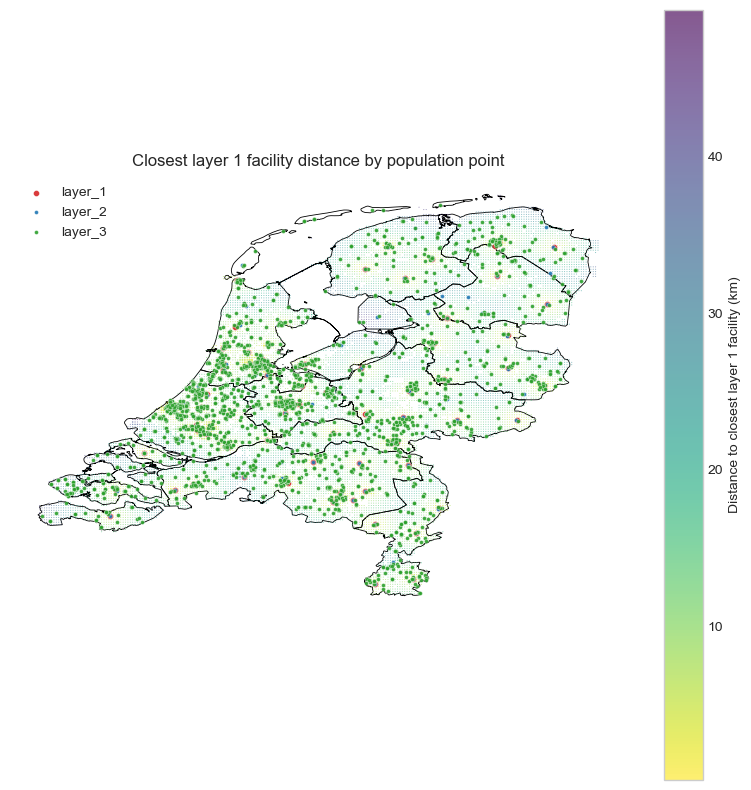

In [164]:
#   First just plotting some basic regions.

import geopandas as gpd
import matplotlib.pyplot as plt

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt


def plot_geography(
    geographies,
    geographic_region,
    ax=None,
    figsize=(8, 8),
    edgecolor="black",
    facecolor="none",
    linewidth=0.6,
    alpha=1.0,
):
    geography = geographies[geographic_region]

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    geography.plot(
        ax=ax,
        edgecolor=edgecolor,
        facecolor=facecolor,
        linewidth=linewidth,
        alpha=alpha,
    )

    ax.set_title(geographic_region)
    ax.set_axis_off()
    ax.set_aspect("equal")

    return fig, ax

def plot_population_points(
    ax,
    points_df,
    lon_col="target_longitude",
    lat_col="target_latitude",
    color_by="distance_km",
    size_by="population",
    cmap="viridis_r",
    alpha=0.65,
):
    q95 = points_df[size_by].quantile(0.95)

    sizes = np.clip(points_df[size_by] / q95, 0.5, 12)

    sc = ax.scatter(
        points_df[lon_col],
        points_df[lat_col],
        c=points_df[color_by],
        s=sizes,
        cmap=cmap,
        alpha=alpha,
        linewidth=0,
    )

    return sc

def plot_facilities(
    ax,
    facilities_enriched,
    layer_col="analysis_layer",
    layer_colors=None,
):
    if layer_colors is None:
        layer_colors = {
            "layer_1": "#d62728",
            "layer_2": "#1f77b4",
            "layer_3": "#2ca02c",
        }

    for layer, group in facilities_enriched.groupby(layer_col):
        ax.scatter(
            group["source_longitude"],
            group["source_latitude"],
            s=18 if layer == "layer_1" else 8,
            c=layer_colors.get(layer, "black"),
            label=layer,
            edgecolor="white",
            linewidth=0.25,
            alpha=0.9,
        )

    ax.legend(loc="best")

    return None


Region_geography = {
    name: gdf.to_crs("EPSG:4326")
    for name, gdf in Region_geography.items()
}

closest = results["netherlands"]["closest"]

layer1 = closest[closest["closest_category"] == "layer_1"].copy()

fig, ax = plot_geography(
    Region_geography,
    "Provinces",
    figsize=(8, 8),
    edgecolor="black",
    facecolor="none",
)

sc = plot_population_points(
    ax,
    layer1,
    color_by="distance_km",
    size_by="population",
)

plot_facilities(
    ax,
    facilities_enriched,
    layer_col="analysis_layer",
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Distance to closest layer 1 facility (km)")

ax.set_title("Closest layer 1 facility distance by population point")
fig.tight_layout()
plt.show()

In [161]:
results["netherlands"]["closest"].info()

<class 'pandas.DataFrame'>
RangeIndex: 65936 entries, 0 to 65935
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   target_id         65936 non-null  str    
 1   source_id         65936 non-null  str    
 2   total_dist        65936 non-null  float64
 3   facility_id       65936 non-null  str    
 4   facility_name     65936 non-null  str    
 5   layer             65936 non-null  str    
 6   analysis_layer    65936 non-null  str    
 7   target_longitude  65936 non-null  float64
 8   target_latitude   65936 non-null  float64
 9   population        65936 non-null  float64
 10  closest_category  65936 non-null  str    
 11  distance_km       65936 non-null  float64
dtypes: float64(5), str(7)
memory usage: 14.0 MB
